In [905]:
#%pip install matplotlib
#%pip install seaborn
#%pip install Jinja2
#%pip install scikit-learn
#%pip install missingno
#!pip install --upgrade missingno


## **ЦЕЛЬ ПРОЕКТА:** 
### **Определить, какие факторы (здоровье, атака, защита, количество способностей, разновидность, скорость поимки) формируют покемона каждой категории.**

В данном случае, цель состоит в том, чтобы классифицировать покемонов на категории обычный, саб легендарный, мифический и легендарный на основе набора признаков и данных о покемонах. Значит, имеем модель классификации. Целевая переменная - категория (status). Цель задачи — предсказать, к какой категории относится покемон, основываясь на других признаках. 

1. Загрузка библиотек

In [7]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_palette('cubehelix')

In [907]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import missingno as msno

2. Импорт данных (https://www.kaggle.com/datasets/mariotormo/complete-pokemon-dataset-updated-090420)

In [8]:
df = pd.read_csv("pokedex.csv")

display(df.head(7))
pd.set_option('display.max_columns', None)

,Unnamed: 0,pokedex_number,name,german_name,japanese_name,generation,status,species,type_number,type_1,...,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,0,1,Bulbasaur,Bisasam,フシギダネ (Fushigidane),1,Normal,Seed Pokémon,2,Grass,...,1.0,2.0,2.0,1.00,1.0,1.0,1.0,1.0,1.0,0.5
1,1,2,Ivysaur,Bisaknosp,フシギソウ (Fushigisou),1,Normal,Seed Pokémon,2,Grass,...,1.0,2.0,2.0,1.00,1.0,1.0,1.0,1.0,1.0,0.5
2,2,3,Venusaur,Bisaflor,フシギバナ (Fushigibana),1,Normal,Seed Pokémon,2,Grass,...,1.0,2.0,2.0,1.00,1.0,1.0,1.0,1.0,1.0,0.5
3,3,3,Mega Venusaur,Bisaflor,フシギバナ (Fushigibana),1,Normal,Seed Pokémon,2,Grass,...,1.0,2.0,2.0,1.00,1.0,1.0,1.0,1.0,1.0,0.5
4,4,4,Charmander,Glumanda,ヒトカゲ (Hitokage),1,Normal,Lizard Pokémon,1,Fire,...,2.0,1.0,1.0,0.50,2.0,1.0,1.0,1.0,0.5,0.5
5,5,5,Charmeleon,Glutexo,リザード (Lizardo),1,Normal,Flame Pokémon,1,Fire,...,2.0,1.0,1.0,0.50,2.0,1.0,1.0,1.0,0.5,0.5
6,6,6,Charizard,Glurak,リザードン (Lizardon),1,Normal,Flame Pokémon,2,Fire,...,0.0,1.0,1.0,0.25,4.0,1.0,1.0,1.0,0.5,0.5


**Информационный лист (описание датасета):**

**pokedex_number** - номер записи покемона в Национальном Покедексе

**name** - английское название покемона

**german_name** - немецкое название покемона

**japanese_name** - оригинальное японское название покемона

**generation** - поколение, в котором покемон был впервые представлен

**status** - категория покемона

**species** - разновидность покемона

**type_number** - количество типов, которые есть у покемона

**type_1** - основной тип покемона

**type_2** - вторичный тип покемона, если он у него есть

**height_m** - рост покемона (м)

**weight_kg** - вес покемона (кг)

**abilities_number** - количество способностей покемона

**ability_1** - название первой способности покемона

**ability_2** - название второй способности покемона

**ability_hidden** - название скрытой способности покемона, если она у него есть

**total_points** - суммарные очки

**hp** - базовое здоровье покемона

**attack** - базовая атака покемона

**defense** - базовая защита покемона

**sp_attack** - базовая специальная атака покемона

**sp_defense** - базовая специальная защита покемона

**speed** - базовая скорость покемона




**catch_rate** - скорость поимки покемона

**base_friendship** - базовая дружба покемонов

**base_experience** - базовый опыт дикого покемона при поимке

**growth_rate** - скорость роста покемона


**egg_type_number** - количество групп, в которых может вылупиться покемон

**egg_type_1** - название первой группы яиц, из которой может вылупиться покемон
 
**egg_type_2** - название второй группы яиц, из которой может вылупиться покемон

**percentage_male** - процент видов, которые являются самцами (пусто, если покемон бесполый)

**egg_cycles** - количество циклов (255-257 шагов), необходимых для вылупления яйца покемона



**against_normal** - количество урона, полученного от атаки обычного типа

**against_fire** - количество урона, полученного от атаки огненного типа

**against_water** - количество урона, полученного от атаки водного типа

**against_electric** - количество урона, полученного от атаки электрического типа

**against_grass** - количество урона, полученного от атаки травяного типа

**against_ice** - количество урона, полученного от атаки ледяного типа

**against_fight** - количество урона, полученного от атаки боевого типа

**against_poison** - количество урона, полученного от атаки яда

**against_ground** - количество урона, полученного от атаки наземного типа

**against_flying** - количество урона, полученного от атаки летающего типа

**against_psychic** - количество урона, полученного от атаки телекинетического типа

**against_bug** - количество урона, полученного от атаки жука

**against_rock** - количество урона, полученного от атаки каменного типа

**against_ghost** - количество урона, полученного от атаки призрака

**against_dragon** - количество урона, полученного от атаки дракона

**against_dark** - количество урона, полученного от атаки темного типа

**against_steel** - количество урона, полученного от атаки стального типа

**against_fairy** - количество урона, полученного от атаки фей

**Датасет состоит из:**
- 1028 наблюдений (строк)
- 51 признака (столбцов)

In [909]:
df.shape

(1028, 51)

**Данные распределены:**
- 38 категорий числового типа (32 float64 и 6 int64)
- 13 категорий текстового типа (object) 

In [910]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 51 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1028 non-null   int64  
 1   pokedex_number    1028 non-null   int64  
 2   name              1028 non-null   object 
 3   german_name       938 non-null    object 
 4   japanese_name     938 non-null    object 
 5   generation        1028 non-null   int64  
 6   status            1028 non-null   object 
 7   species           1028 non-null   object 
 8   type_number       1028 non-null   int64  
 9   type_1            1028 non-null   object 
 10  type_2            542 non-null    object 
 11  height_m          1028 non-null   float64
 12  weight_kg         1027 non-null   float64
 13  abilities_number  1028 non-null   int64  
 14  ability_1         1025 non-null   object 
 15  ability_2         513 non-null    object 
 16  ability_hidden    810 non-null    object 


In [911]:
df.isna().sum()

Unnamed: 0            0
pokedex_number        0
name                  0
german_name          90
japanese_name        90
generation            0
status                0
species               0
type_number           0
type_1                0
type_2              486
height_m              0
weight_kg             1
abilities_number      0
ability_1             3
ability_2           515
ability_hidden      218
total_points          0
hp                    0
attack                0
defense               0
sp_attack             0
sp_defense            0
speed                 0
catch_rate          104
base_friendship     104
base_experience     104
growth_rate           1
egg_type_number       0
egg_type_1            3
egg_type_2          746
percentage_male     236
egg_cycles            1
against_normal        0
against_fire          0
against_water         0
against_electric      0
against_grass         0
against_ice           0
against_fight         0
against_poison        0
against_ground  

### Исследование данных



In [912]:
missing_data = df.isnull().sum()
exclude_columns = ['type_2', 'ability_2', 'ability_hidden', 'egg_type_2', 'percentage_male']
missing_data = df.drop(columns=exclude_columns).isnull().sum()
print(missing_data[missing_data > 0])

german_name         90
japanese_name       90
weight_kg            1
ability_1            3
catch_rate         104
base_friendship    104
base_experience    104
growth_rate          1
egg_type_1           3
egg_cycles           1
dtype: int64


В датасете присутствует 501 пропуск, наибольшее количество из них в таких показателях как: скорость поимки, базовая дружба и базовый опыт, а также немецкое и японское имя

In [913]:
print(f"Pokedex has {df.duplicated().sum()} duplicated data")

Pokedex has 0 duplicated data


В датасете 0 дубликатов

In [914]:
df.describe(include="object")

,name,german_name,japanese_name,status,species,type_1,type_2,ability_1,ability_2,ability_hidden,growth_rate,egg_type_1,egg_type_2
count,1028,938,938,1028,1028,1028,542,1025,513,810,1027,1025,282
unique,1028,807,807,4,641,18,18,202,126,154,6,15,11
top,Bulbasaur,Rotom,ロトム (Rotom),Normal,Mouse Pokémon,Water,Flying,Levitate,Frisk,Telepathy,Medium Fast,Field,Water 1
freq,1,6,6,915,12,134,109,41,17,21,432,258,76


Для выполнения задачи анализа и прогнозирования данные выглядят актуальными и достаточными, поскольку включают разнообразные количественные и категориальные признаки, связанные с жизненными характеристиками и особенностями каждого покемона.

### Исследуем признаки детальнее
1. **'status'** включает в себя 4 категории: обычный, саб легендарный, мифический, легендарный

In [915]:
df["status"].value_counts()

status
Normal           915
Sub Legendary     45
Legendary         39
Mythical          29
Name: count, dtype: int64

Проверим средние суммарные очки по жизненным показателям в каждой категории покемонов

In [916]:
a = df[["status", "total_points"]]

b = a[a["status"] == "Normal"]
c = a[a["status"] == "Sub Legendary"]
d = a[a["status"] == "Mythical"]
e = a[a["status"] == "Legendary"]

In [917]:
b['total_points'].mean()

415.20983606557377

In [918]:
c['total_points'].mean()

581.4222222222222

In [919]:
d['total_points'].mean()

594.4827586206897

In [920]:
e['total_points'].mean()

679.5641025641025

Можно заметить, что с повышением статуса покемона растут средние суммарные очки

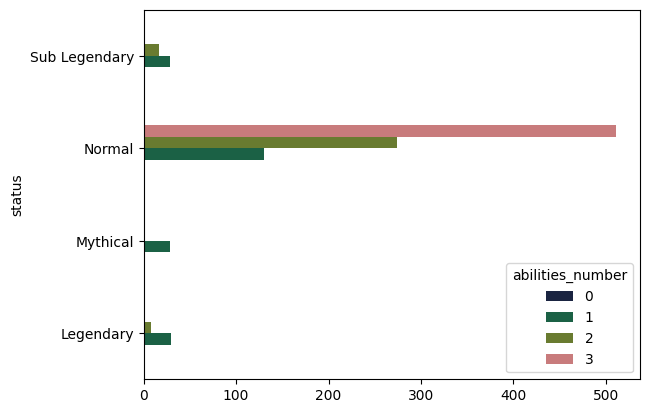

In [921]:
pd.crosstab(df["status"], df["abilities_number"]).plot.barh(stacked=False);

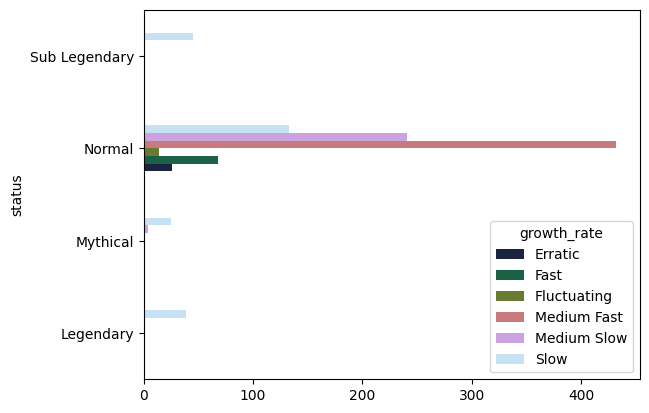

In [922]:
pd.crosstab(df["status"], df["growth_rate"]).plot.barh(stacked=False);

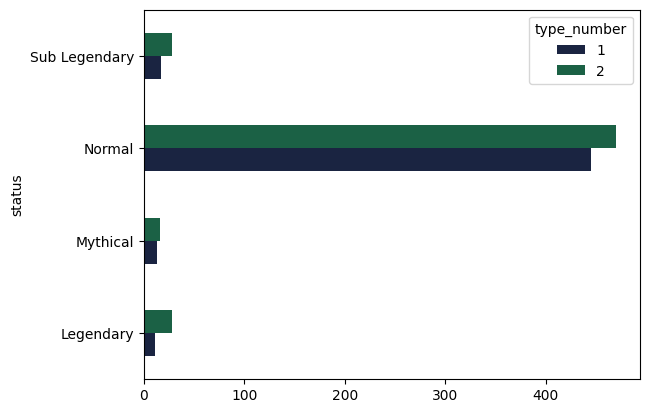

In [923]:
pd.crosstab(df["status"], df["type_number"]).plot.barh(stacked=False);

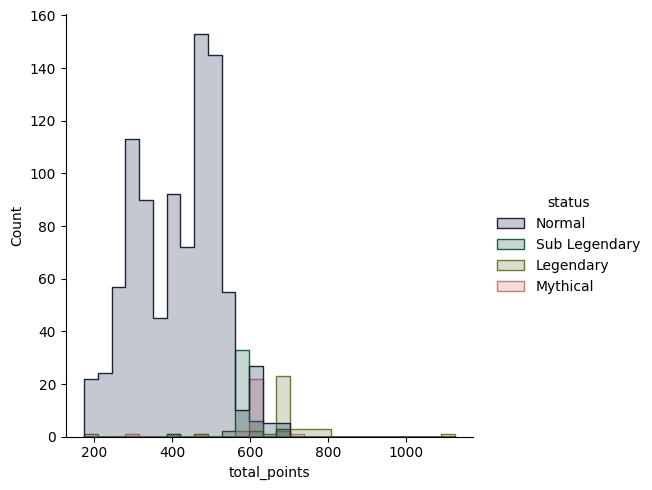

In [924]:
sns.displot(df, x="total_points", hue="status", element="step")

**Вывод**

На графиках видно:
- количество способностей обычных покемонов может достигать 3, саб легендарные и легендарные могут иметь максимально лишь 2 способности, мифические - 1;
- по сравнению с обычными покемонами, все остальные категории отличаются крайне низкой скоростью роста; 
- независимо от категории покемоны чаще всего имеют 2 типа; 
- большая часть мифических, саб легендарных и легендарных покемонов по суммарным очкам превышают обычных покемонов.

2. **'type_1'** включает в себя 18 категорий: травяной, огненный, водный, жук, обычный, темный, ядовитый, электрический, наземный, ледяной, фея, стальной, боевой, психический, каменный, призрак, дракон, летающий

In [925]:
df["type_1"].unique()

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Dark', 'Poison',
       'Electric', 'Ground', 'Ice', 'Fairy', 'Steel', 'Fighting',
       'Psychic', 'Rock', 'Ghost', 'Dragon', 'Flying'], dtype=object)

In [926]:
df["type_1"].value_counts()

type_1
Water       134
Normal      115
Grass        91
Bug          81
Psychic      76
Fire         65
Electric     61
Rock         60
Dark         44
Ground       41
Ghost        41
Dragon       40
Poison       39
Fighting     38
Ice          36
Steel        36
Fairy        22
Flying        8
Name: count, dtype: int64

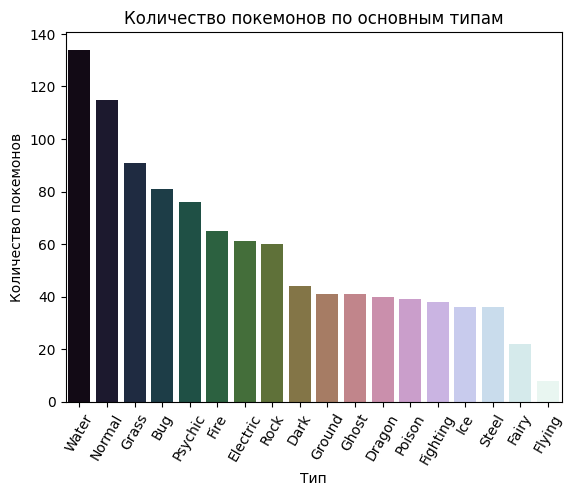

In [927]:
type_counts = df['type_1'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='cubehelix')
plt.title('Количество покемонов по основным типам')
plt.xlabel('Тип')
plt.ylabel('Количество покемонов')
plt.xticks(rotation=60)
plt.show()

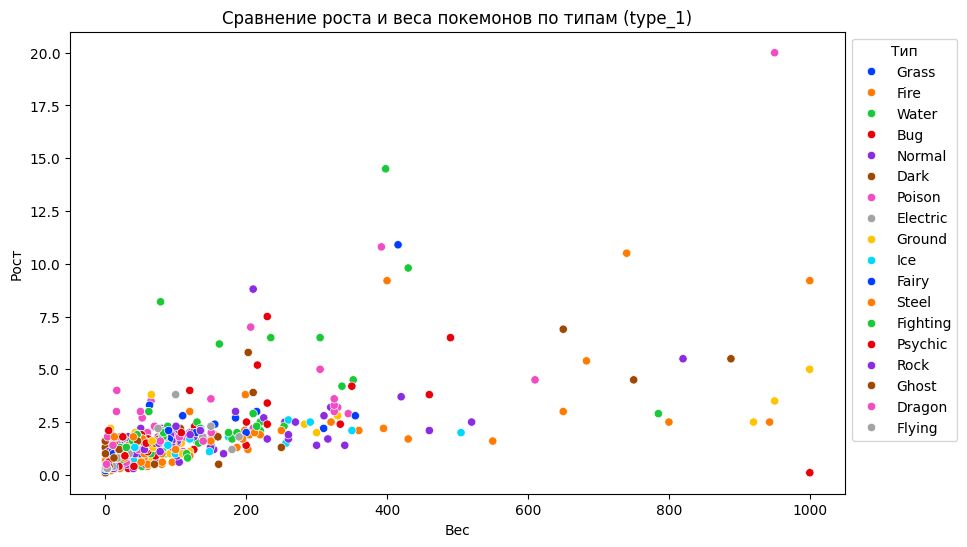

In [928]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight_kg', y='height_m', hue='type_1', palette='bright')
plt.title('Сравнение роста и веса покемонов по типам (type_1)')
plt.xlabel('Вес')
plt.ylabel('Рост')
plt.legend(title='Тип', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()


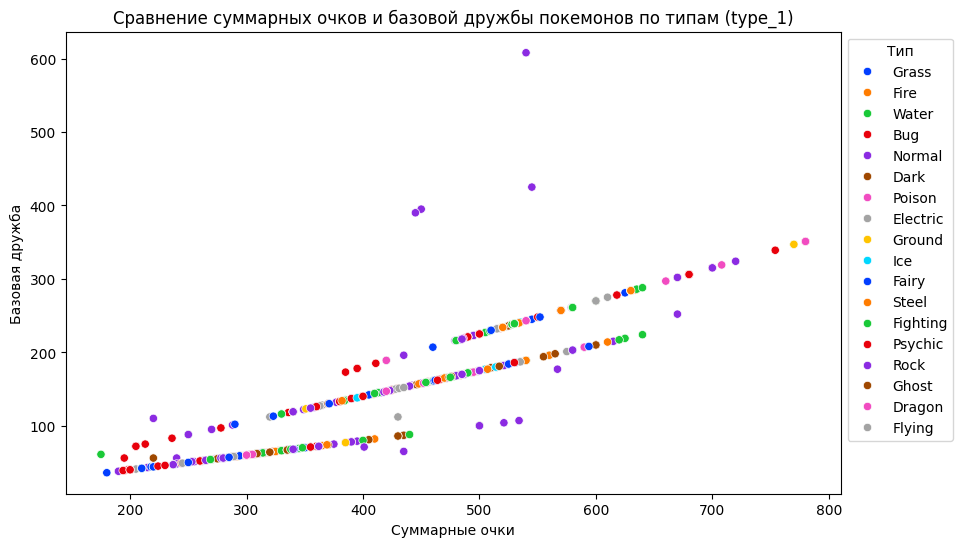

In [929]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_points', y='base_experience', hue='type_1', palette='bright')
plt.title('Сравнение суммарных очков и базовой дружбы покемонов по типам (type_1)')
plt.xlabel('Суммарные очки')
plt.ylabel('Базовая дружба')
plt.legend(title='Тип', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()


In [930]:
matching_count = df[df['type_1'] == df['type_2']].shape[0]
print(f"Количество покемонов с совпадающими основными и вторичными типами: {matching_count}")

Количество покемонов с совпадающими основными и вторичными типами: 0


In [931]:
type_counts = df.groupby(['type_1', 'type_2']).size().reset_index(name='count')
type_counts_sorted = type_counts.sort_values(by='count', ascending=False)
print("\nКоличество покемонов по каждому сочетанию type_1 и type_2:")
print(type_counts_sorted)


Количество покемонов по каждому сочетанию type_1 и type_2:
       type_1    type_2  count
108    Normal    Flying     27
84      Grass    Poison     15
4         Bug    Flying     14
8         Bug    Poison     12
73      Ghost     Grass     11
..        ...       ...    ...
62       Fire      Rock      1
138      Rock  Fighting      1
50   Fighting       Ice      1
49   Fighting     Ghost      1
170     Water     Steel      1

[171 rows x 3 columns]


**Вывод**

На графиках видно:
- самый распространенный основной тип покемона - водный, самый редкий - летающий;
- рассматривая по основным типам покемонов, их рост и вес распределен хаотично, явная зависимость не отслеживается; 
- прослеживается прямо пропорциональное увеличение базовой друдбы при увеличении суммарных очков. болшая часть покемонов лежит в определенной линии тренда, исключения - покемоны обычного основного типа; 
- бпокемоны с одинаковыми основным и вторичным типами отсутсвуют, самая распространенная комбинация - основного типа обычный и вторичного летающий, затем - пара травяной и ядовитый.

3. **'ability_hidden'** включает в себя 154 уникальных значений скрытых способностей у покемонов

In [932]:
df["ability_hidden"].nunique()

154

In [933]:
df["ability_hidden"].value_counts()

ability_hidden
Telepathy        21
Sheer Force      18
Overcoat         17
Unnerve          17
Weak Armor       15
                 ..
Immunity          1
Honey Gather      1
Compound Eyes     1
White Smoke       1
Stalwart          1
Name: count, Length: 154, dtype: int64

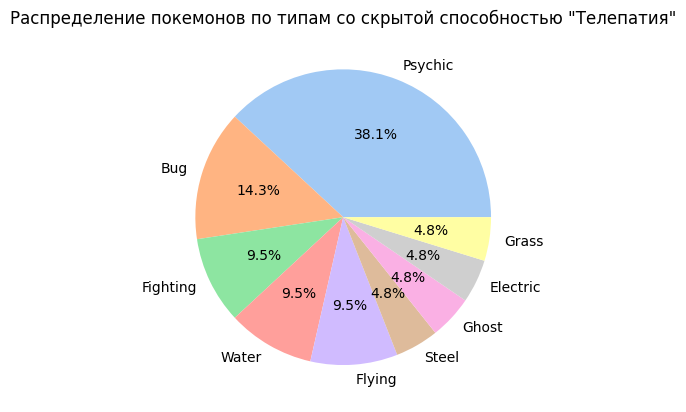

In [934]:
sns.set_palette('pastel')
filtered_pokemons = df[df['ability_hidden'] == 'Telepathy']
type_counts = filtered_pokemons['type_1'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
plt.title('Распределение покемонов по типам со скрытой способностью "Телепатия"')
plt.show()

In [935]:
missing_abilities_count = df['ability_hidden'].isnull().sum()
print(f"\nКоличество покемонов без скрытых способностей: {missing_abilities_count}")


Количество покемонов без скрытых способностей: 218


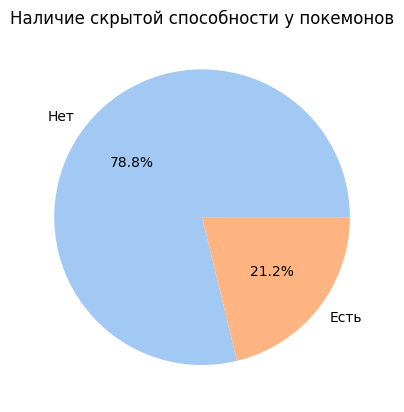

In [936]:
ability_counts = df['ability_hidden'].notnull().value_counts() 
ability_counts.index = ['Нет', 'Есть']

plt.pie(ability_counts, labels=ability_counts.index, autopct='%1.1f%%')
plt.title('Наличие скрытой способности у покемонов')
sns.set_palette('pastel')
plt.show()

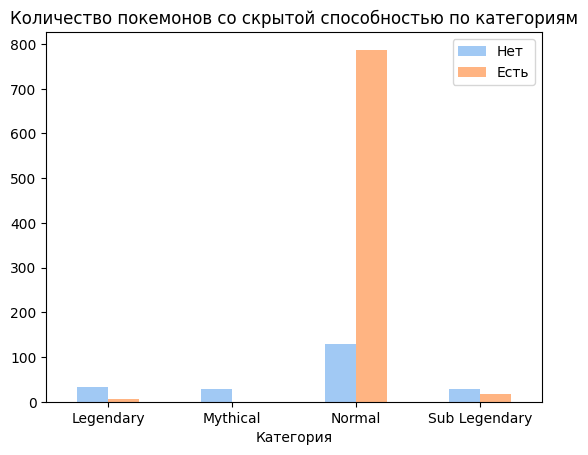

In [937]:
ability_counts = df.groupby(['status', df['ability_hidden'].notnull()]).size().unstack(fill_value=0)
ability_counts.columns = ['Нет', 'Есть']
ability_counts.plot(kind='bar')
plt.title('Количество покемонов со скрытой способностью по категориям')
plt.xlabel('Категория')
plt.xticks(rotation=0) 
plt.show()

**Вывод**

На графиках видно:
- скрытая способность отсутсвует у 218 покемонов, существует 154 уникальных скрытых способностей;
- самая распространенная скрытая способность - телепатия, она встречается у покемонов 9 основных типа, чаще всего - среди психических;
- скрытая способность присутствует у 21.2% покемонов;
- большая часть скрытых способностей приходится на покемонов обычной категории, также встречаются у саб легендарных покемонов, у легендарных и мифических они отсутсвуют. 

In [938]:
num_var = ["total_points", "hp", "attack", "defense", "speed"]
cat_var = ["growth_rate", "type_1", "type_2", "egg_type_1", "egg_type_2"]
target = "status"

In [939]:
df[num_var].describe()

,total_points,hp,attack,defense,speed
count,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000
mean,437.571984,69.577821,80.119650,74.475681,68.534047
std,121.664910,26.385849,32.372321,31.303309,29.802103
min,175.000000,1.000000,5.000000,5.000000,5.000000
25%,330.000000,50.000000,55.000000,50.000000,45.000000
50%,455.000000,66.500000,76.000000,70.000000,65.000000
75%,510.000000,80.000000,100.000000,90.000000,90.000000
max,1125.000000,255.000000,190.000000,250.000000,180.000000


In [940]:
def num_dist(data, var):
    fig, ax = plt.subplots(1, 2, figsize=(20, 4))
    
    sns.histplot(data=data, x=var, kde=True, ax=ax[0])
    sns.boxplot(data=data, x=var, ax=ax[1])
    ax[0].set_title(f"{var} Distribution Histogram")
    ax[1].set_title(f"{var} Distribution Boxplot")

    plt.show()

def cat_dist(data, var):
    fig, ax = plt.subplots(1, 2, figsize=(20, 4))

    data[var].value_counts().sort_values(ascending=False).plot(kind="pie", explode=[0.05 for _ in data[var].dropna().unique()], autopct='%1.1f%%', ax=ax[0], shadow=True)
    ax[0].set_title(f"{var} Pie Chart")
    ax[0].set_ylabel('')
   
    count = sns.countplot(x=var, data=data, order=data[var].value_counts().sort_values(ascending=False).index, ax=ax[1])
    for bar in count.patches:
        count.annotate(format(bar.get_height()),
            (bar.get_x() + bar.get_width() / 2,
            bar.get_height()), ha='center', va='center',
            size=10, xytext=(0, 2),
            textcoords='offset points')
    ax[1].set_title(f"{var} Bar Chart")
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
    plt.show()

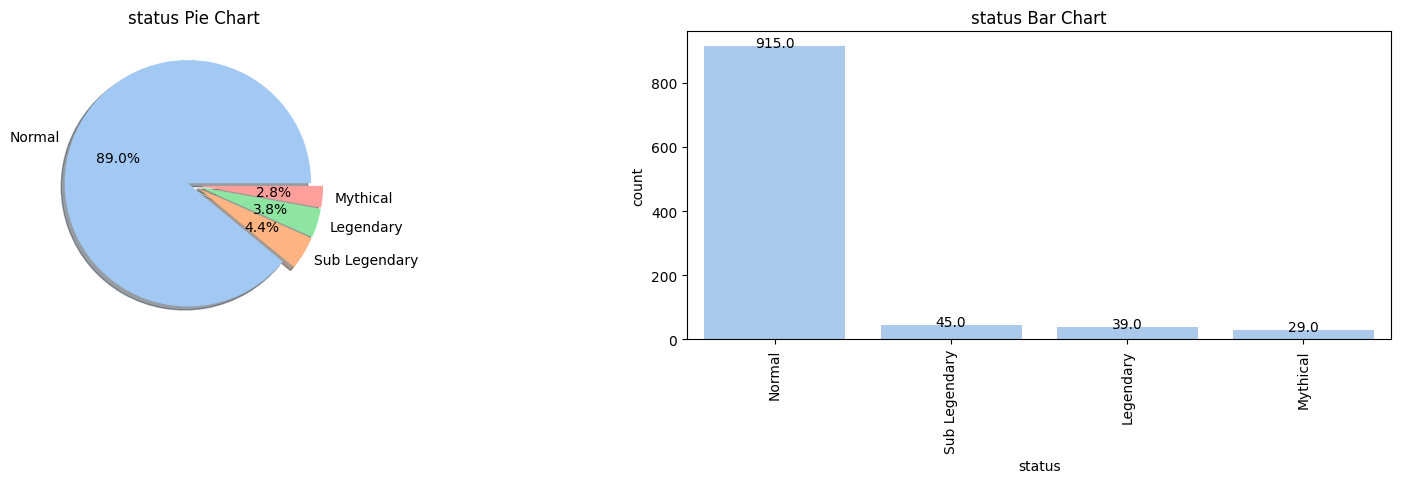

In [941]:
cat_dist(df, "status")
sns.set_palette('pastel')

**Вывод**

На всех отличных от обычных покемонов приходится 11%: саб легендарных 4.4%, легендарных 3.8%, мифических 2.8%. В числовом выражении это 45, 39, и 29 покемонов соответсвенно. 

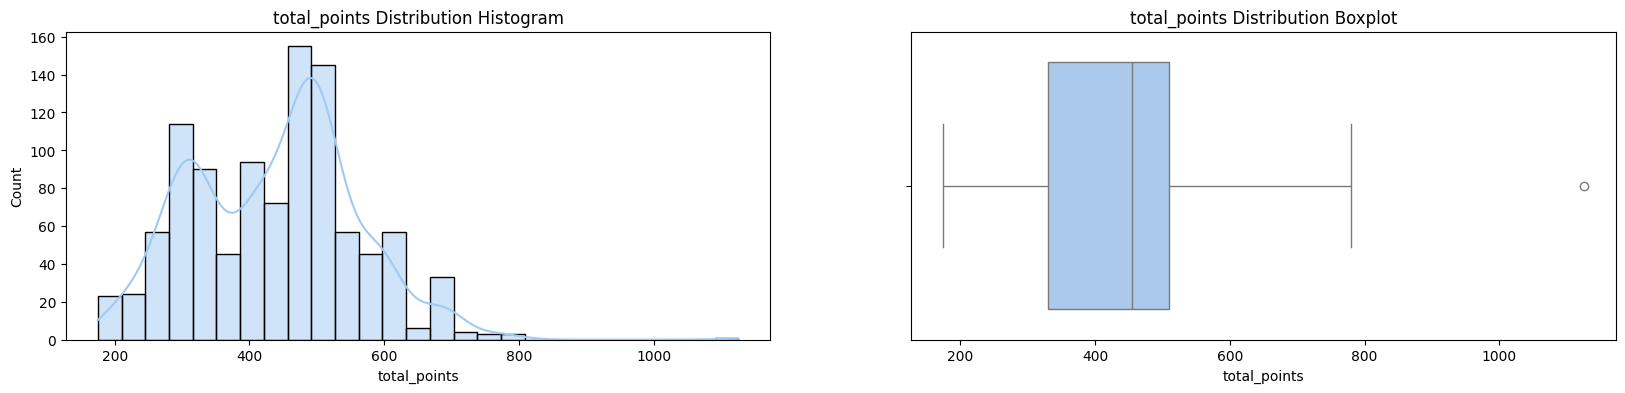

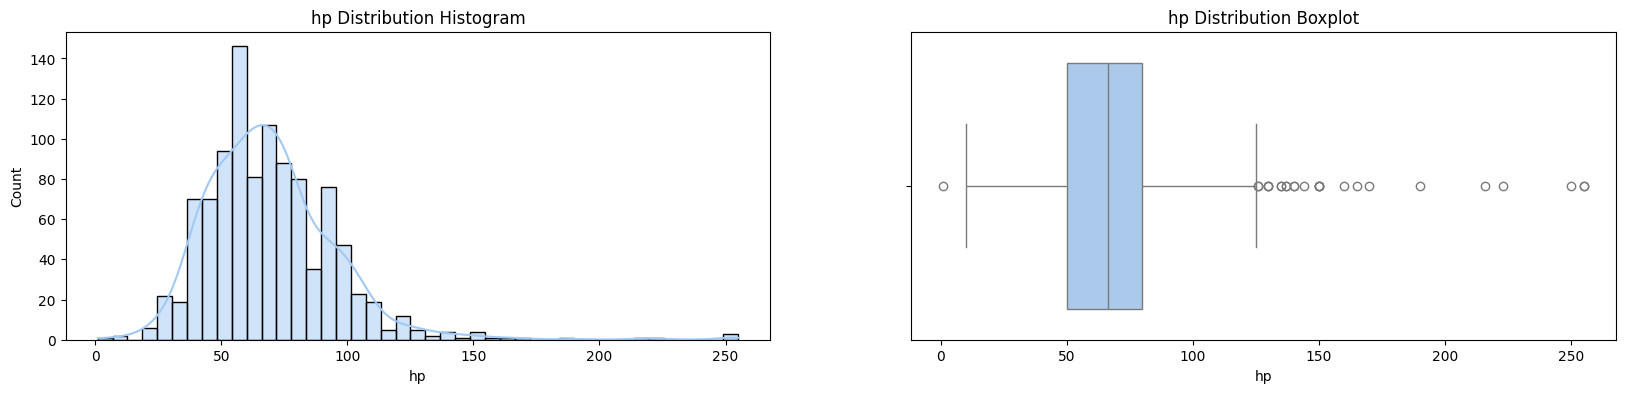

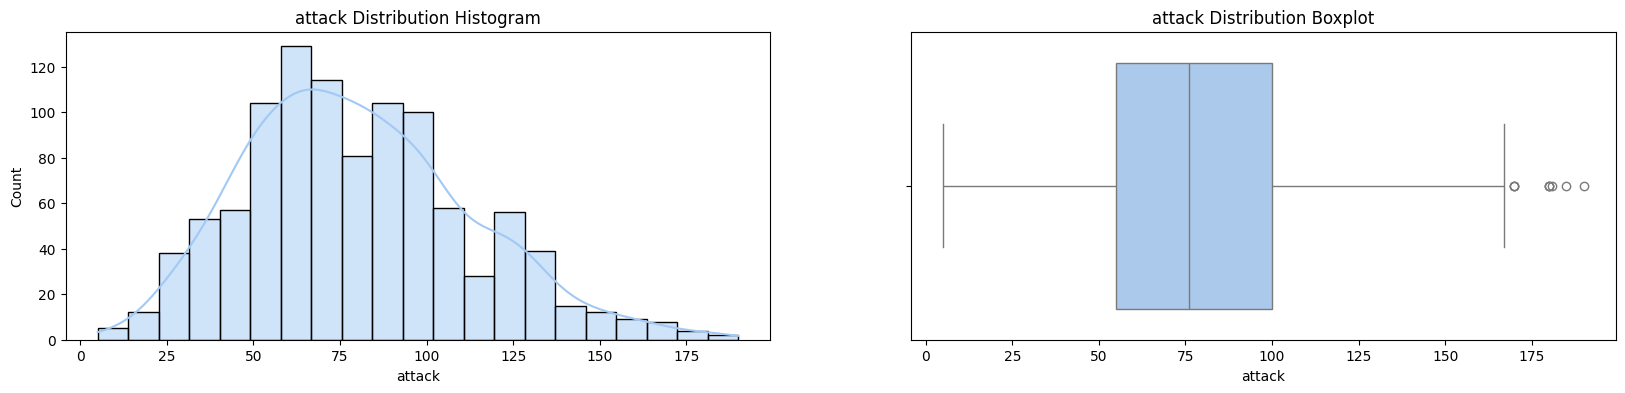

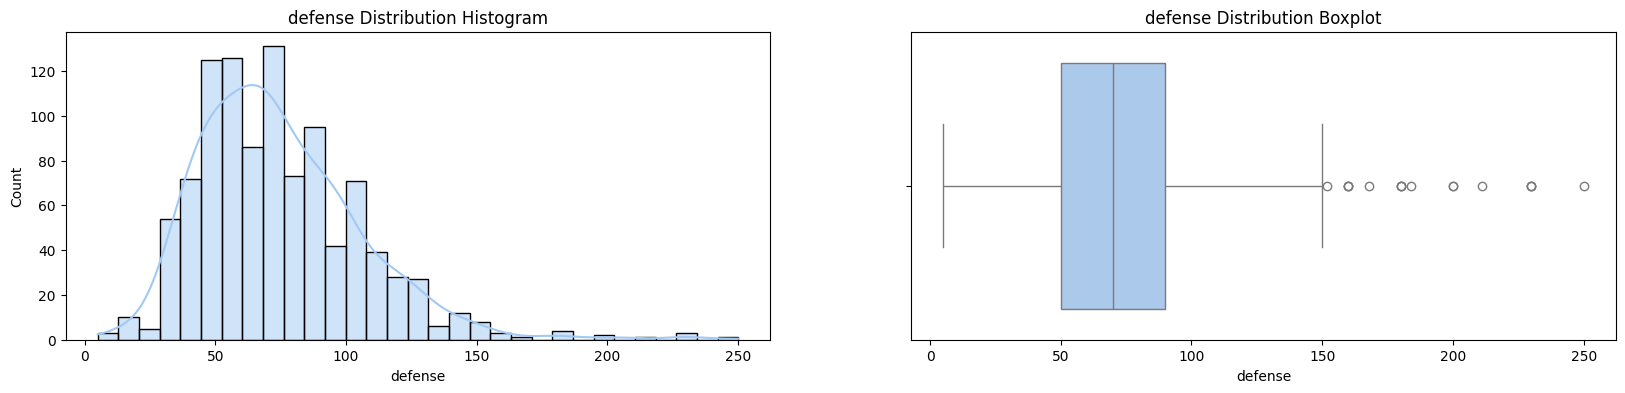

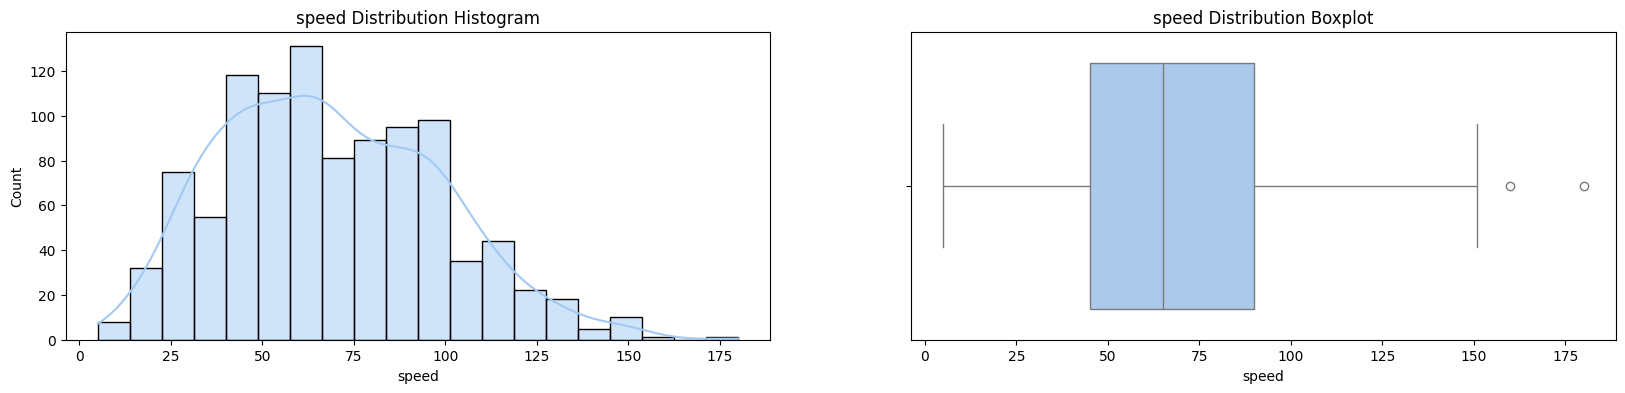

In [942]:
for var in num_var:
    num_dist(df, var)

**Вывод**

Суммарные очки - по данным графика мы можем сделать вывод о том, что большинство покемонов имеет суммарные очки от 350 до 500, в среднем 450. 

Здоровье - большинство покемонов обладает здоровьем в пределах 50-80.

Атака - атака большинства покемонов находится в пределах 55-100.

Защита -  большинство покемонов имеет защиту в пределах 50-90.

Скорость - скорость большинства покемонов находится в пределах 45-80.

Данные показатели имеют явные выбросы в данных, но это связано в индивидуальными характеристиками каждого покемона, данные выбросы могут напрямую влиять на редкость.

Также можно подробнее исследовать выбросы данных - boxplot показывает выбросы, надо их посмотреть и сравнить с другими данными

In [943]:
df[df.total_points > 800]

,Unnamed: 0,pokedex_number,name,german_name,japanese_name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
1027,1027,890,Eternatus Eternamax,NaN,NaN,8,Legendary,Gigantic Pokémon,2,Poison,Dragon,100.0,NaN,0,NaN,NaN,NaN,1125.0,255.0,115.0,250.0,125.0,250.0,130.0,NaN,NaN,NaN,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,0.5,0.5,0.5,0.25,2.0,0.5,0.5,2.0,1.0,2.0,0.5,1.0,1.0,2.0,1.0,1.0,1.0


In [944]:
df[df.hp > 130]

,Unnamed: 0,pokedex_number,name,german_name,japanese_name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
53,53,40,Wigglytuff,Knuddeluff,プクリン (Pukurin),1,Normal,Balloon Pokémon,2,Normal,Fairy,1.0,12.0,3,Cute Charm,Competitive,Frisk,435.0,140.0,70.0,45.0,85.0,50.0,45.0,50.0,70.0,196.0,Fast,1,Fairy,NaN,25.0,10.0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,2.0,1.0,1.0,1.00,0.50,1.0,0.0,0.0,0.5,2.0,1.0
145,145,113,Chansey,Chaneira,ラッキー (Lucky),1,Normal,Egg Pokémon,1,Normal,NaN,1.1,34.6,3,Natural Cure,Serene Grace,Healer,450.0,250.0,5.0,5.0,35.0,105.0,50.0,30.0,140.0,395.0,Fast,1,Fairy,NaN,0.0,40.0,1.0,1.0,1.0,1.0,1.00,1.0,2.0,1.0,1.0,1.0,1.00,1.00,1.0,0.0,1.0,1.0,1.0,1.0
181,181,143,Snorlax,Relaxo,カビゴン (Kabigon),1,Normal,Sleeping Pokémon,1,Normal,NaN,2.1,460.0,3,Immunity,Thick Fat,Gluttony,540.0,160.0,110.0,65.0,65.0,110.0,30.0,25.0,70.0,189.0,Slow,1,Monster,NaN,87.5,40.0,1.0,1.0,1.0,1.0,1.00,1.0,2.0,1.0,1.0,1.0,1.00,1.00,1.0,0.0,1.0,1.0,1.0,1.0
243,243,202,Wobbuffet,Woingenau,ソーナンス (Sonans),2,Normal,Patient Pokémon,1,Psychic,NaN,1.3,28.5,2,Shadow Tag,NaN,Telepathy,405.0,190.0,33.0,58.0,33.0,58.0,33.0,45.0,70.0,142.0,Medium Fast,1,Amorphous,NaN,50.0,20.0,1.0,1.0,1.0,1.0,1.00,1.0,0.5,1.0,1.0,1.0,0.50,2.00,1.0,2.0,1.0,2.0,1.0,1.0
288,288,242,Blissey,Heiteira,ハピナス (Happinas),2,Normal,Happiness Pokémon,1,Normal,NaN,1.5,46.8,3,Natural Cure,Serene Grace,Healer,540.0,255.0,10.0,10.0,75.0,135.0,55.0,30.0,140.0,608.0,Fast,1,Fairy,NaN,0.0,40.0,1.0,1.0,1.0,1.0,1.00,1.0,2.0,1.0,1.0,1.0,1.00,1.00,1.0,0.0,1.0,1.0,1.0,1.0
342,342,289,Slaking,Letarking,ケッキング (Kekking),3,Normal,Lazy Pokémon,1,Normal,NaN,2.0,130.5,1,Truant,NaN,NaN,670.0,150.0,160.0,100.0,95.0,65.0,100.0,45.0,70.0,252.0,Slow,1,Field,NaN,50.0,15.0,1.0,1.0,1.0,1.0,1.00,1.0,2.0,1.0,1.0,1.0,1.00,1.00,1.0,0.0,1.0,1.0,1.0,1.0
350,350,297,Hariyama,Hariyama,ハリテヤマ (Hariteyama),3,Normal,Arm Thrust Pokémon,1,Fighting,NaN,2.3,253.8,3,Thick Fat,Guts,Sheer Force,474.0,144.0,120.0,60.0,40.0,60.0,50.0,200.0,70.0,166.0,Fluctuating,1,Human-Like,NaN,75.0,20.0,1.0,0.5,1.0,1.0,1.00,0.5,1.0,1.0,1.0,2.0,2.00,0.50,0.5,1.0,1.0,0.5,1.0,2.0
380,380,321,Wailord,Wailord,ホエルオー (Whaloh),3,Normal,Float Whale Pokémon,1,Water,NaN,14.5,398.0,3,Water Veil,Oblivious,Pressure,500.0,170.0,90.0,45.0,90.0,45.0,60.0,60.0,70.0,175.0,Fluctuating,2,Field,Water 2,50.0,40.0,1.0,0.5,0.5,2.0,2.00,0.5,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5,1.0
505,505,426,Drifblim,Drifzepeli,フワライド (Fuwaride),4,Normal,Blimp Pokémon,2,Ghost,Flying,1.2,15.0,3,Aftermath,Unburden,Flare Boost,498.0,150.0,80.0,44.0,90.0,54.0,80.0,60.0,70.0,174.0,Fluctuating,1,Amorphous,NaN,50.0,30.0,0.0,1.0,1.0,2.0,0.50,2.0,0.0,0.5,0.0,1.0,1.00,0.25,2.0,2.0,1.0,2.0,1.0,1.0
527,527,446,Munchlax,Mampfaxo,ゴンベ (Gonbe),4,Normal,Big Eater Pokémon,1,Normal,NaN,0.6,105.0,3,Pickup,Thick Fat,Gluttony,390.0,135.0,85.0,40.0,40.0,85.0,5.0,50.0,70.0,78.0,Slow,1,Undiscovered,NaN,87.5,40.0,1.0,1.0,1.0,1.0,1.00,1.0,2.0,1.0,1.0,1.0,1.00,1.00,1.0,0.0,1.0,1.0,1.0,1.0


In [945]:
df[df.attack > 150]

,Unnamed: 0,pokedex_number,name,german_name,japanese_name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
162,162,127,Mega Pinsir,Pinsir,カイロス (Kailios),1,Normal,Stag Beetle Pokémon,2,Bug,Flying,1.7,59.0,1,Aerilate,NaN,NaN,600.0,65.0,155.0,120.0,65.0,90.0,105.0,45.0,70.0,210.0,Slow,1,Bug,NaN,50.0,25.0,1.0,2.0,1.0,2.0,0.25,2.00,0.25,1.0,0.0,2.0,1.00,0.50,4.0,1.0,1.0,1.0,1.0,1.0
166,166,130,Mega Gyarados,Garados,ギャラドス (Gyarados),1,Normal,Atrocious Pokémon,2,Water,Dark,6.5,305.0,1,Mold Breaker,NaN,NaN,640.0,95.0,155.0,109.0,70.0,130.0,81.0,45.0,70.0,224.0,Slow,2,Dragon,Water 2,50.0,5.0,1.0,0.5,0.5,2.0,2.00,0.50,2.00,1.0,1.0,1.0,0.00,2.00,1.0,0.5,1.0,0.5,0.5,2.0
189,189,150,Mega Mewtwo X,Mewtu,ミュウツー (Mewtwo),1,Legendary,Genetic Pokémon,2,Psychic,Fighting,2.3,127.0,1,Steadfast,NaN,NaN,780.0,106.0,190.0,100.0,154.0,100.0,130.0,3.0,0.0,351.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,1.0,1.0,1.0,1.00,1.00,0.50,1.0,1.0,2.0,1.00,1.00,0.5,2.0,1.0,1.0,1.0,2.0
258,258,214,Mega Heracross,Skaraborn,ヘラクロス (Heracros),2,Normal,Single Horn Pokémon,2,Bug,Fighting,1.7,62.5,1,Skill Link,NaN,NaN,600.0,80.0,185.0,115.0,40.0,105.0,75.0,45.0,70.0,210.0,Slow,1,Bug,NaN,50.0,25.0,1.0,2.0,1.0,1.0,0.50,1.00,0.50,1.0,0.5,4.0,2.00,0.50,1.0,1.0,1.0,0.5,1.0,2.0
295,295,248,Mega Tyranitar,Despotar,バンギラス (Bangiras),2,Normal,Armor Pokémon,2,Rock,Dark,2.5,255.0,1,Sand Stream,NaN,NaN,700.0,100.0,164.0,150.0,95.0,120.0,71.0,45.0,35.0,315.0,Slow,1,Monster,NaN,50.0,40.0,0.5,0.5,2.0,1.0,2.00,1.00,4.00,0.5,2.0,0.5,0.00,2.00,1.0,0.5,1.0,0.5,2.0,2.0
306,306,257,Mega Blaziken,Lohgock,バシャーモ (Bursyamo),3,Normal,Blaze Pokémon,2,Fire,Fighting,1.9,52.0,1,Speed Boost,NaN,NaN,630.0,80.0,160.0,80.0,130.0,80.0,100.0,45.0,70.0,284.0,Medium Slow,1,Field,NaN,87.5,20.0,1.0,0.5,2.0,1.0,0.50,0.50,1.00,1.0,2.0,2.0,2.00,0.25,1.0,1.0,1.0,0.5,0.5,1.0
342,342,289,Slaking,Letarking,ケッキング (Kekking),3,Normal,Lazy Pokémon,1,Normal,NaN,2.0,130.5,1,Truant,NaN,NaN,670.0,150.0,160.0,100.0,95.0,65.0,100.0,45.0,70.0,252.0,Slow,1,Field,NaN,50.0,15.0,1.0,1.0,1.0,1.0,1.00,1.00,2.00,1.0,1.0,1.0,1.00,1.00,1.0,0.0,1.0,1.0,1.0,1.0
419,419,354,Mega Banette,Banette,ジュペッタ (Juppeta),3,Normal,Marionette Pokémon,1,Ghost,NaN,1.2,13.0,1,Prankster,NaN,NaN,555.0,64.0,165.0,75.0,93.0,83.0,75.0,45.0,35.0,194.0,Fast,1,Amorphous,NaN,50.0,25.0,0.0,1.0,1.0,1.0,1.00,1.00,0.00,0.5,1.0,1.0,1.00,0.50,1.0,2.0,1.0,2.0,1.0,1.0
456,456,383,Primal Groudon,Groudon,グラードン (Groudon),3,Legendary,Continent Pokémon,2,Ground,Fire,5.0,999.7,1,Desolate Land,NaN,NaN,770.0,100.0,180.0,160.0,150.0,90.0,90.0,5.0,0.0,347.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,0.5,0.0,0.0,1.00,1.00,1.00,0.5,2.0,1.0,1.00,0.50,1.0,1.0,1.0,1.0,0.5,0.5
458,458,384,Mega Rayquaza,Rayquaza,レックウザ (Rayquaza),3,Legendary,Sky High Pokémon,2,Dragon,Flying,10.8,392.0,1,Delta Stream,NaN,NaN,780.0,105.0,180.0,100.0,180.0,100.0,115.0,3.0,0.0,351.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,0.5,0.5,0.5,0.25,2.00,0.50,1.0,0.0,1.0,1.00,0.50,1.0,1.0,2.0,1.0,1.0,2.0


In [946]:
df[df.defense > 150]

,Unnamed: 0,pokedex_number,name,german_name,japanese_name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
105,105,80,Mega Slowbro,Lahmus,ヤドラン (Yadoran),1,Normal,Hermit Crab Pokémon,2,Water,Psychic,2.0,120.0,1,Shell Armor,NaN,NaN,590.0,95.0,75.0,180.0,130.0,80.0,30.0,75.0,70.0,207.0,Medium Fast,2,Monster,Water 1,50.0,20.0,1.00,0.5,0.5,2.0,2.00,0.50,0.5,1.00,1.0,1.00,0.5,2.0,1.00,2.0,1.0,2.0,0.5,1.0
119,119,91,Cloyster,Austos,パルシェン (Parshen),1,Normal,Bivalve Pokémon,2,Water,Ice,1.5,132.5,3,Shell Armor,Skill Link,Overcoat,525.0,50.0,95.0,180.0,85.0,45.0,70.0,60.0,70.0,184.0,Slow,1,Water 3,NaN,50.0,20.0,1.00,1.0,0.5,2.0,2.00,0.25,2.0,1.00,1.0,1.00,1.0,1.0,2.00,1.0,1.0,1.0,1.0,1.0
124,124,95,Onix,Onix,イワーク (Iwark),1,Normal,Rock Snake Pokémon,2,Rock,Ground,8.8,210.0,3,Rock Head,Sturdy,Weak Armor,385.0,35.0,45.0,160.0,30.0,45.0,70.0,45.0,70.0,77.0,Medium Fast,1,Mineral,NaN,50.0,25.0,0.50,0.5,4.0,0.0,4.00,2.00,2.0,0.25,2.0,0.50,1.0,1.0,0.50,1.0,1.0,1.0,2.0,1.0
249,249,208,Steelix,Stahlos,ハガネール (Haganeil),2,Normal,Iron Snake Pokémon,2,Steel,Ground,9.2,400.0,3,Rock Head,Sturdy,Sheer Force,510.0,75.0,85.0,200.0,55.0,65.0,30.0,25.0,70.0,179.0,Medium Fast,1,Mineral,NaN,50.0,25.0,0.50,2.0,2.0,0.0,1.00,1.00,2.0,0.00,2.0,0.50,0.5,0.5,0.25,1.0,0.5,1.0,0.5,0.5
250,250,208,Mega Steelix,Stahlos,ハガネール (Haganeil),2,Normal,Iron Snake Pokémon,2,Steel,Ground,10.5,740.0,1,Sand Force,NaN,NaN,610.0,75.0,125.0,230.0,55.0,95.0,30.0,25.0,70.0,214.0,Medium Fast,1,Mineral,NaN,50.0,25.0,0.50,2.0,2.0,0.0,1.00,1.00,2.0,0.00,2.0,0.50,0.5,0.5,0.25,1.0,0.5,1.0,0.5,0.5
256,256,213,Shuckle,Pottrott,ツボツボ (Tsubotsubo),2,Normal,Mold Pokémon,2,Bug,Rock,0.6,20.5,3,Sturdy,Gluttony,Contrary,505.0,20.0,10.0,230.0,10.0,230.0,5.0,190.0,70.0,177.0,Medium Slow,1,Bug,NaN,50.0,20.0,0.50,1.0,2.0,1.0,1.00,1.00,1.0,0.50,1.0,1.00,1.0,1.0,2.00,1.0,1.0,1.0,2.0,1.0
361,361,306,Aggron,Stolloss,ボスゴドラ (Bossgodora),3,Normal,Iron Armor Pokémon,2,Steel,Rock,2.1,360.0,3,Sturdy,Rock Head,Heavy Metal,530.0,70.0,110.0,180.0,60.0,60.0,50.0,45.0,35.0,239.0,Slow,1,Monster,NaN,50.0,35.0,0.25,1.0,2.0,1.0,1.00,0.50,4.0,0.00,4.0,0.25,0.5,0.5,0.50,1.0,0.5,1.0,1.0,0.5
362,362,306,Mega Aggron,Stolloss,ボスゴドラ (Bossgodora),3,Normal,Iron Armor Pokémon,1,Steel,NaN,2.2,395.0,1,Filter,NaN,NaN,630.0,70.0,140.0,230.0,60.0,80.0,50.0,45.0,35.0,284.0,Slow,1,Monster,NaN,50.0,35.0,0.50,1.5,1.0,1.0,0.50,0.50,1.5,0.00,1.5,0.50,0.5,0.5,0.50,1.0,0.5,1.0,0.5,0.5
446,446,377,Regirock,Regirock,レジロック (Regirock),3,Sub Legendary,Rock Peak Pokémon,1,Rock,NaN,1.7,230.0,2,Clear Body,NaN,Sturdy,580.0,80.0,100.0,200.0,50.0,100.0,50.0,3.0,35.0,261.0,Slow,1,Undiscovered,NaN,NaN,80.0,0.50,0.5,2.0,1.0,2.00,1.00,2.0,0.50,2.0,0.50,1.0,1.0,1.00,1.0,1.0,1.0,2.0,1.0
456,456,383,Primal Groudon,Groudon,グラードン (Groudon),3,Legendary,Continent Pokémon,2,Ground,Fire,5.0,999.7,1,Desolate Land,NaN,NaN,770.0,100.0,180.0,160.0,150.0,90.0,90.0,5.0,0.0,347.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.00,0.5,0.0,0.0,1.00,1.00,1.0,0.50,2.0,1.00,1.0,0.5,1.00,1.0,1.0,1.0,0.5,0.5


In [947]:
df[df.speed > 150]

,Unnamed: 0,pokedex_number,name,german_name,japanese_name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
344,344,291,Ninjask,Ninjask,テッカニン (Tekkanin),3,Normal,Ninja Pokémon,2,Bug,Flying,0.8,12.0,2,Speed Boost,NaN,Infiltrator,456.0,61.0,90.0,45.0,50.0,50.0,160.0,120.0,70.0,160.0,Erratic,1,Bug,NaN,50.0,15.0,1.0,2.0,1.0,2.0,0.25,2.0,0.25,1.0,0.0,2.0,1.0,0.5,4.0,1.0,1.0,1.0,1.0,1.0
463,463,386,Deoxys Speed Forme,Deoxys,デオキシス (Deoxys),3,Mythical,DNA Pokémon,1,Psychic,NaN,1.7,60.8,1,Pressure,NaN,NaN,600.0,50.0,95.0,90.0,95.0,90.0,180.0,3.0,0.0,270.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,1.0,1.0,1.0,1.00,1.0,0.50,1.0,1.0,1.0,0.5,2.0,1.0,2.0,1.0,2.0,1.0,1.0
922,922,795,Pheromosa,Schabelle,フェローチェ (Pheroache),7,Sub Legendary,Lissome Pokémon,2,Bug,Fighting,1.8,25.0,1,Beast Boost,NaN,NaN,570.0,71.0,137.0,37.0,137.0,37.0,151.0,45.0,0.0,257.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,2.0,1.0,1.0,0.50,1.0,0.50,1.0,0.5,4.0,2.0,0.5,1.0,1.0,1.0,0.5,1.0,2.0


Исследуя данные срезы данных можно сделать вывод, что большая часть выпадающих из средних значений покемонов - отличные от "обычных":

- Суммарные очки - 1 легендарный. 

- Здоровье - 9 не "обычных" из 20 покемонов.

- Атака - 12 не "обычных" из 23 покемонов.

- Защита - 5 не "обычных" из 16 покемонов.

- Скорость - 2 не "обычных" из 3 покемонов. 

Можно сказать, что при аномально высоких жизненных характеристиках существует вероятность, что данный покемон является не "обычной" категорией.

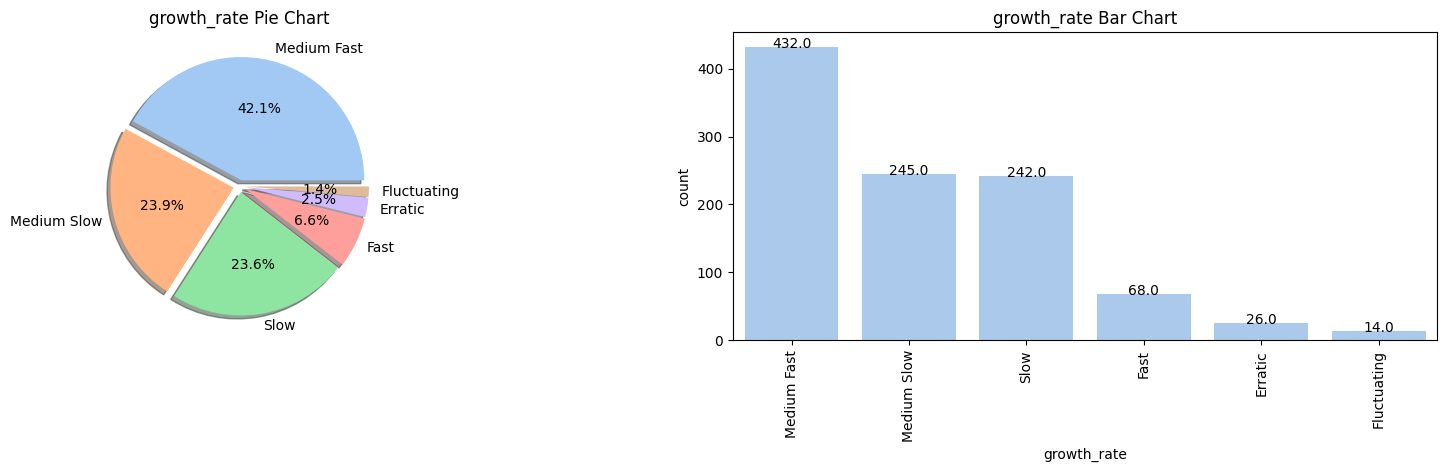

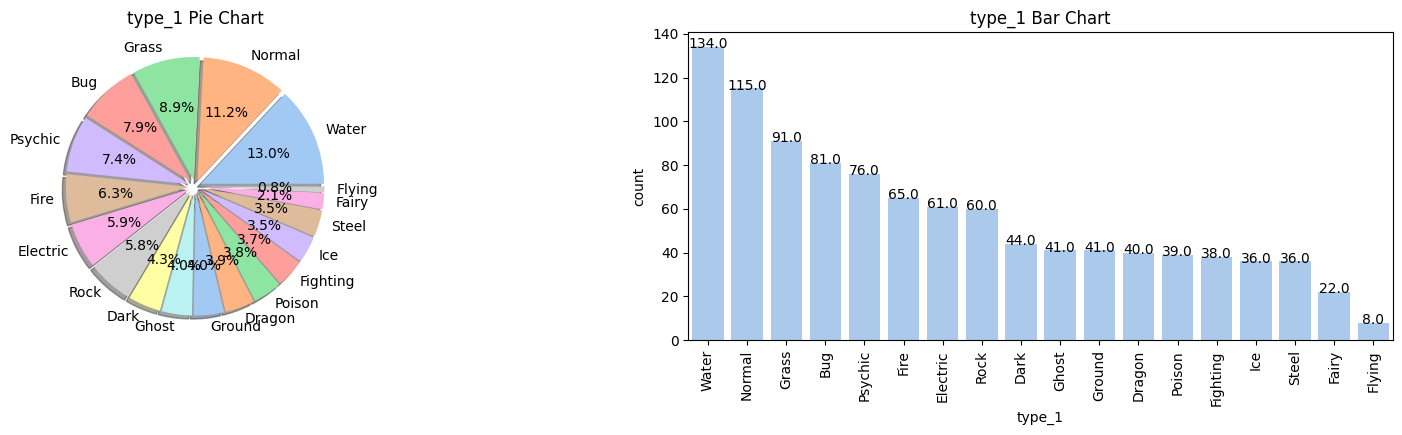

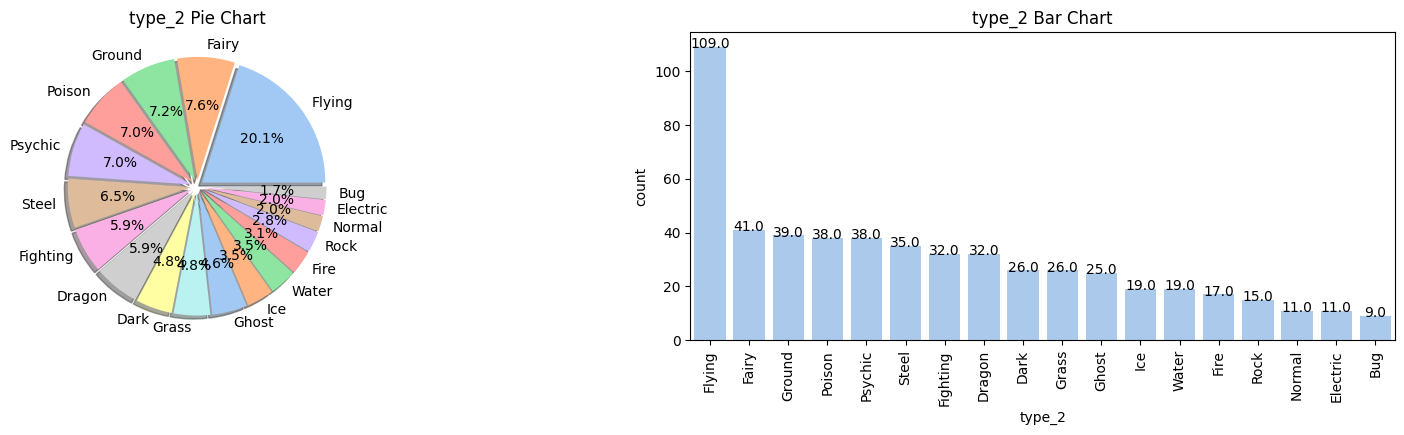

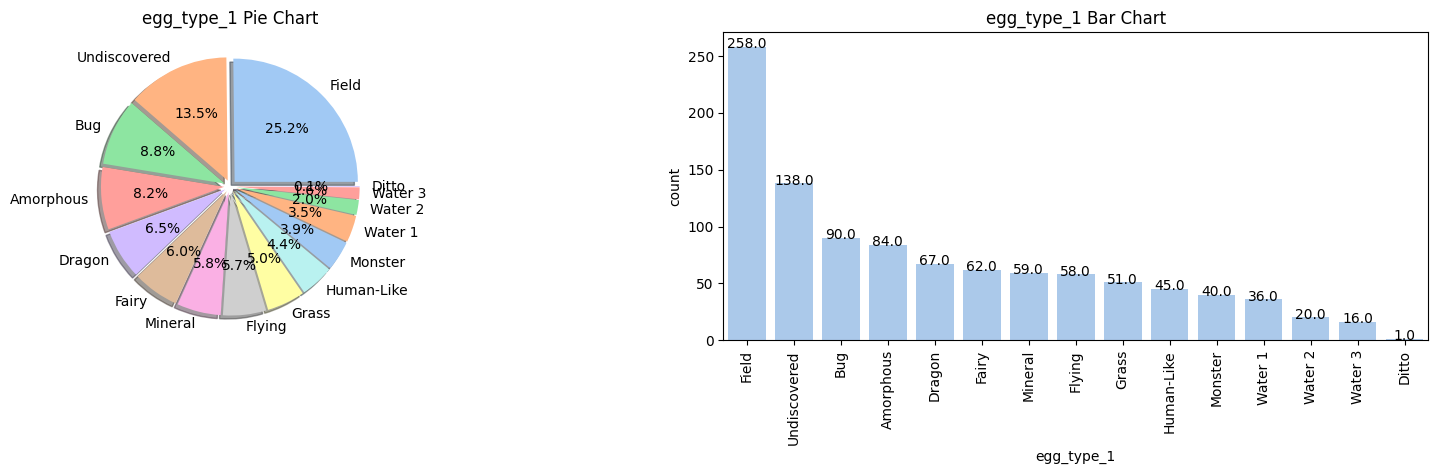

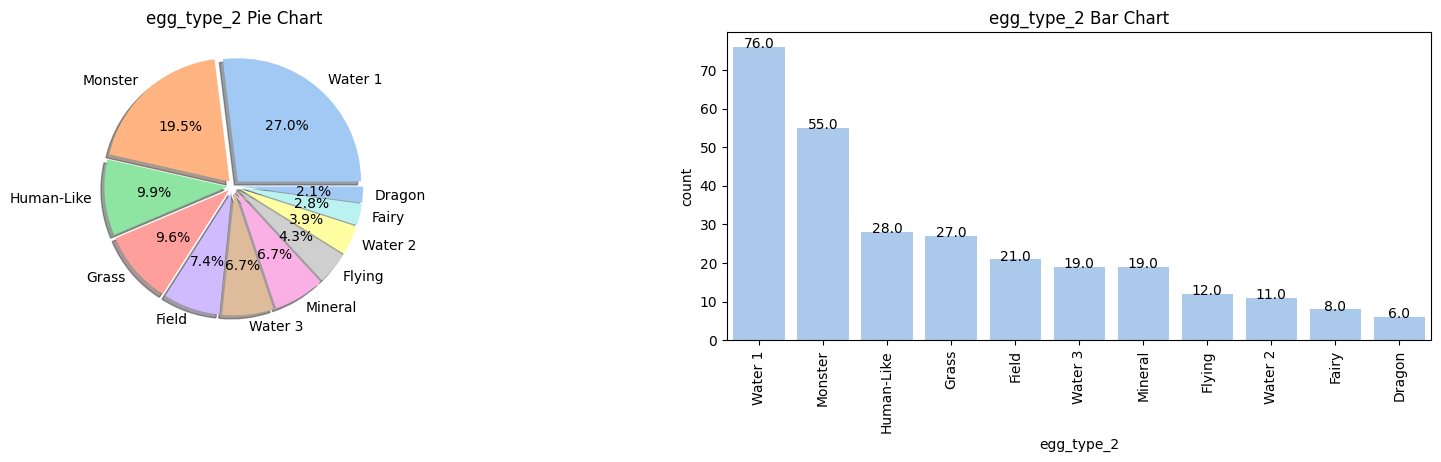

In [948]:
for var in cat_var:
    cat_dist(df, var)


**ВЫВОД**

**Скорость роста** - 42% растут со средне высокой скоростью. (432 покемона).

**Основной тип** - 13% (134) покемонов - водного основного типа.

**Вторичный тип** - примерно 20% летающего вторичного типа (109 покеомнов) .

**Первый тип яиц** - 25% вылупляются из яйца наземной группы (258 покемонов).

**Второй тип яиц** - 27% - из яйца водной 1 группы (76 покемонов). 


## Рассмотрим зависимости не таргет переменных:

In [949]:
a = ["total_points", "hp", "attack", "defense", "speed"]
c = ["growth_rate", "type_1", "type_2", "egg_type_1", "egg_type_2"]
new = "generation"

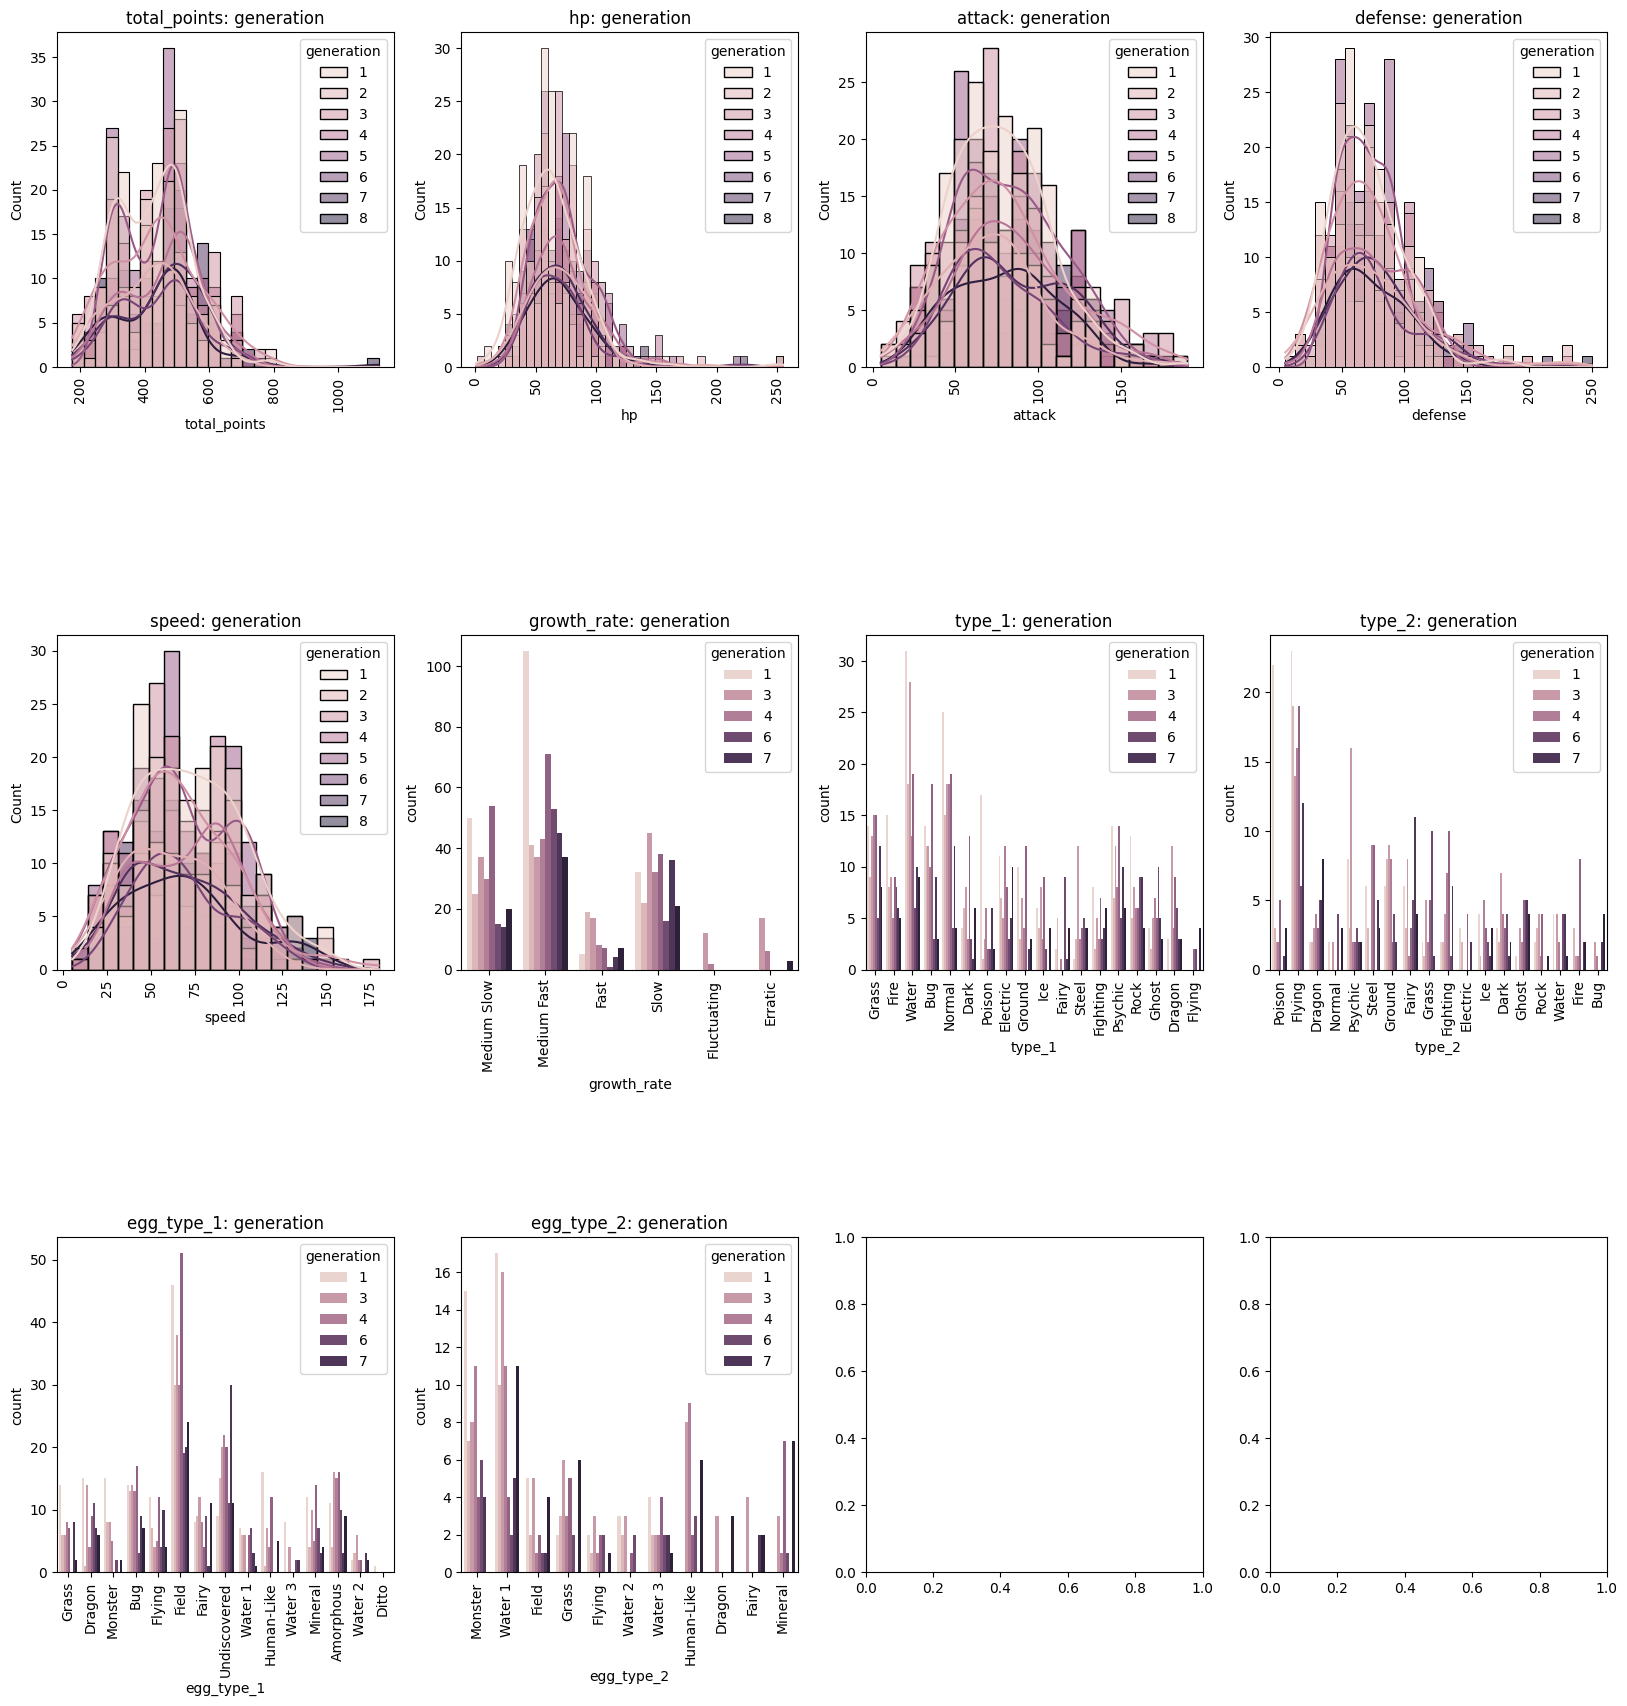

In [950]:
fig, ax = plt.subplots(3, 4, figsize=(20, 20))
ax = ax.flatten()

for i, var in enumerate(a+c):
    if i < 5:
    
        sns.histplot(data=df, x=var, hue=new, kde=True, ax=ax[i])
        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
    else:
        sns.countplot(data=df, x=var, hue=new, ax=ax[i])
        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
    
    ax[i].set_title(f"{var}: generation")

plt.subplots_adjust(hspace=0.8)
     
plt.show()

 **Рассмотрим зависимости не таргетных переменныхых, а именно generation с такими показателями, как total_points, hp, attack, defense, speed, growth_rate, type_1, type_2, egg_type_1, egg_type_2.**

Интересные закономерности можно выявить на графике **"generation" с числовыми показателями** : 

- имеем много выбросов, так как какая-то часть покемонов выбивается из средних суммарных очков, соответственно, могут отноиться к категориям, отличной от "обычный". Большая часть покемонов в каждой точке суммарынх очков представлена разной ступени поколения. Из этого, мы можем сделать вывод, что поколение не сильно влияет на суммарные очки, а скорее является одним из факторов. Данные выводы можно сделать по каждой числовой категории, представленной на графиках. 
- однако, можно заметить, что чаще всего выбиваются из распределения справа покемоны, с более высоккими ступенями поколения. То есть вероятность, что у покемона, с категорией, отличной от "обычный", будут большие числовые статистические показатели существует.

На графиках  **"generation" с категориальными показателями** :
- несмотря на то, что покемоны с поколением "7" одинаково часто представлены со скоростями развития "медленно" и "средне медленно" , покемонов поколения "6" в первой категории скорости намного больше. Однако со "средне быстрой" скоростью развития покемонов высоких стадий поколения еще больше, что дает сделать вывод, что поколение покемона не зависит от его скорости развития.
- покемоны высших стадий поколения встречаются довольно часто в большинстве основных типов, однако такое не прослеживается во вторичных типах. Можно сделать вывод, что поколение покемона напрямую зависит от вторичного типа и самого его наличия у покемона.
- рассматривая гарфики типов яиц, можно заметить наивысшее преобладание высших стадий поколений покемонов в "наземный" и "неизведанный" в первой группе яиц, из которой можт вылупиться покемона, и "водный-1", "травяной", "человекоподобный", "дракон", "минералный". Тем самым, при обнаружении яйца, одной из этих групп вероятность вылупления покемона высшей стадии поколения в будущем намного выше.

## Матрица корреляций

In [951]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
correlation_matrix

,Unnamed: 0,pokedex_number,generation,type_number,height_m,weight_kg,abilities_number,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience,egg_type_number,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
Unnamed: 0,1.000000,0.999906,0.986797,0.046052,0.064980,0.105823,-0.136660,0.124940,0.104689,0.111840,0.096858,0.094309,0.086455,0.009270,-0.122909,-0.173147,0.121668,-0.010538,-0.030684,0.205156,-0.147684,0.045069,-0.062762,-0.065489,-0.082184,0.035765,-0.023882,0.037817,0.008927,0.000412,-0.081095,-0.001704,-0.036555,0.087736,0.019862,0.040562,0.089292,0.148223
pokedex_number,0.999906,1.000000,0.987363,0.047197,0.065249,0.105325,-0.136059,0.123960,0.103872,0.111108,0.095951,0.093608,0.085762,0.009163,-0.121716,-0.173524,0.121119,-0.009576,-0.031172,0.204015,-0.148048,0.045761,-0.062251,-0.066533,-0.083384,0.035749,-0.024048,0.036979,0.009905,0.000515,-0.080117,-0.003093,-0.036091,0.087270,0.019666,0.039593,0.089897,0.148325
generation,0.986797,0.987363,1.000000,0.031877,0.053983,0.069397,-0.112315,0.068375,0.069593,0.071636,0.054243,0.051468,0.042590,-0.013840,-0.075735,-0.132255,0.074523,0.014960,-0.015462,0.132832,-0.121608,0.052117,-0.058328,-0.059223,-0.091174,0.030904,-0.028570,0.061116,0.016811,0.024742,-0.058940,-0.005997,-0.026261,0.061721,-0.001326,0.016132,0.076969,0.122618
type_number,0.046052,0.047197,0.031877,1.000000,0.082697,0.114335,-0.048927,0.208692,0.092114,0.137665,0.200221,0.162319,0.152104,0.089256,-0.155169,-0.082459,0.184674,0.034118,-0.034920,0.071041,-0.248177,0.114713,0.073098,0.017116,-0.078104,0.234210,-0.068957,-0.153174,-0.034445,0.068512,-0.050951,-0.127603,0.188302,0.093188,0.003516,0.025548,0.051990,0.069253
height_m,0.064980,0.065249,0.053983,0.082697,1.000000,0.662133,-0.170339,0.375629,0.378987,0.205641,0.306427,0.202691,0.309210,0.139065,-0.364914,-0.359748,0.493859,-0.032161,0.046255,0.251765,-0.005022,-0.063970,-0.033564,-0.035955,-0.030024,0.060924,-0.010432,-0.070157,0.046012,-0.034826,0.056196,-0.037566,-0.032266,0.018181,0.157561,0.002605,-0.012100,0.040780
weight_kg,0.105823,0.105325,0.069397,0.114335,0.662133,1.000000,-0.231220,0.478514,0.445611,0.417837,0.465327,0.245504,0.296864,0.060157,-0.314399,-0.419128,0.437577,-0.089547,0.046052,0.448510,-0.137786,-0.034371,0.075643,-0.106587,0.022773,0.000921,0.156563,-0.228003,0.155324,-0.141768,-0.086425,-0.040002,-0.125004,0.052146,0.107897,0.025682,-0.005184,0.058305
abilities_number,-0.136660,-0.136059,-0.112315,-0.048927,-0.170339,-0.231220,1.000000,-0.421573,-0.160460,-0.319026,-0.244504,-0.395842,-0.291539,-0.266850,0.357027,0.286152,-0.412362,0.053590,-0.183131,-0.473906,0.099134,-0.004082,0.013732,0.063574,0.101112,-0.026816,0.104223,0.070307,0.078860,0.040126,0.055300,-0.004194,-0.010542,-0.186672,-0.077531,-0.119951,0.026767,-0.026187
total_points,0.124940,0.123960,0.068375,0.208692,0.375629,0.478514,-0.421573,1.000000,0.650141,0.733509,0.631085,0.733534,0.721923,0.562561,-0.729481,-0.324593,0.929548,-0.087220,0.124001,0.536424,-0.081822,-0.085216,-0.010652,-0.045364,-0.041540,0.047453,0.005787,-0.098731,0.046792,-0.099071,-0.065548,-0.018558,-0.047840,0.132302,0.117357,0.067964,-0.005153,0.116639
hp,0.104689,0.103872,0.069593,0.092114,0.378987,0.445611,-0.160460,0.650141,1.000000,0.442992,0.302593,0.369335,0.399167,0.188629,-0.469756,-0.139626,0.653806,-0.060266,-0.040784,0.371861,0.048753,-0.104837,-0.018727,-0.037143,0.030359,0.069182,0.092735,-0.029254,0.004689,-0.054250,-0.004471,0.013136,-0.054032,-0.056778,0.143139,-0.003416,0.033001,0.131081
attack,0.111840,0.111108,0.071636,0.137665,0.205641,0.417837,-0.319026,0.733509,0.442992,1.000000,0.450766,0.376205,0.264264,0.381040,-0.520068,-0.308925,0.639233,-0.063925,0.200393,0.379261,-0.104381,-0.

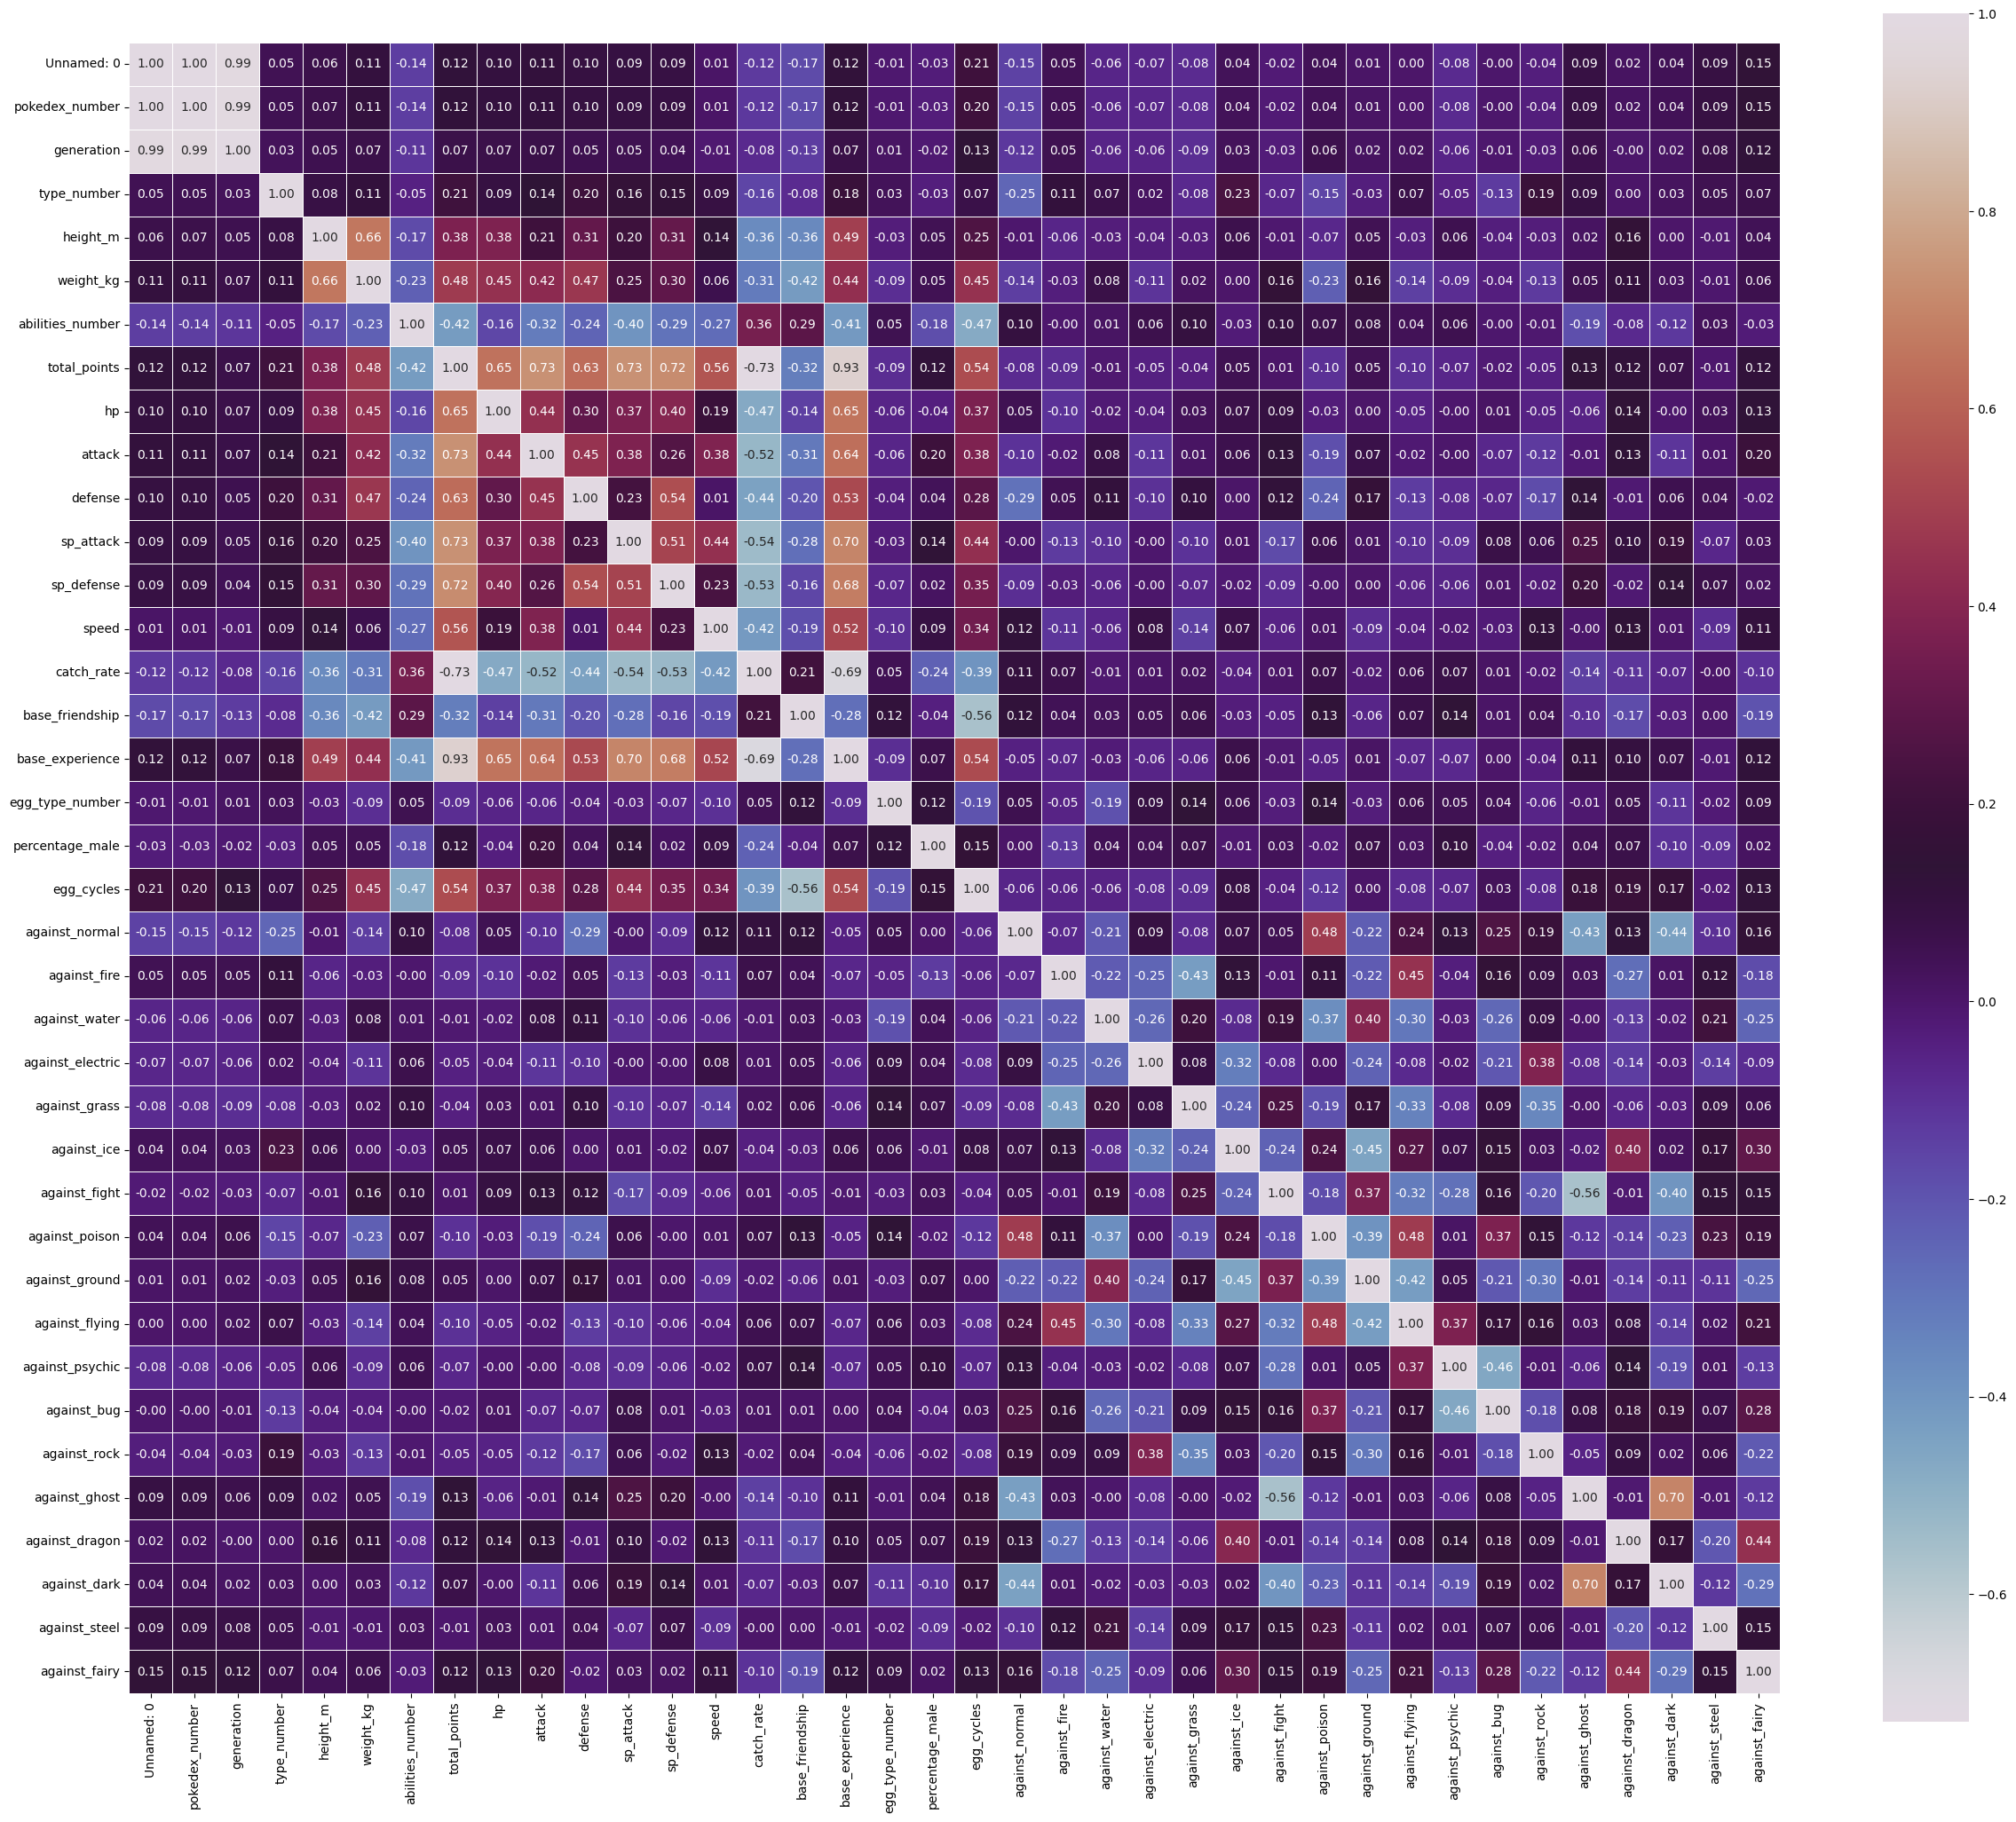

In [952]:
plt.figure(figsize=(30, 25))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='twilight', square=True, cbar=True, linewidths=.5)
plt.show()

## Зависимость количества урона против покемонов, определенного вида, от вида самого покемона

<Axes: >

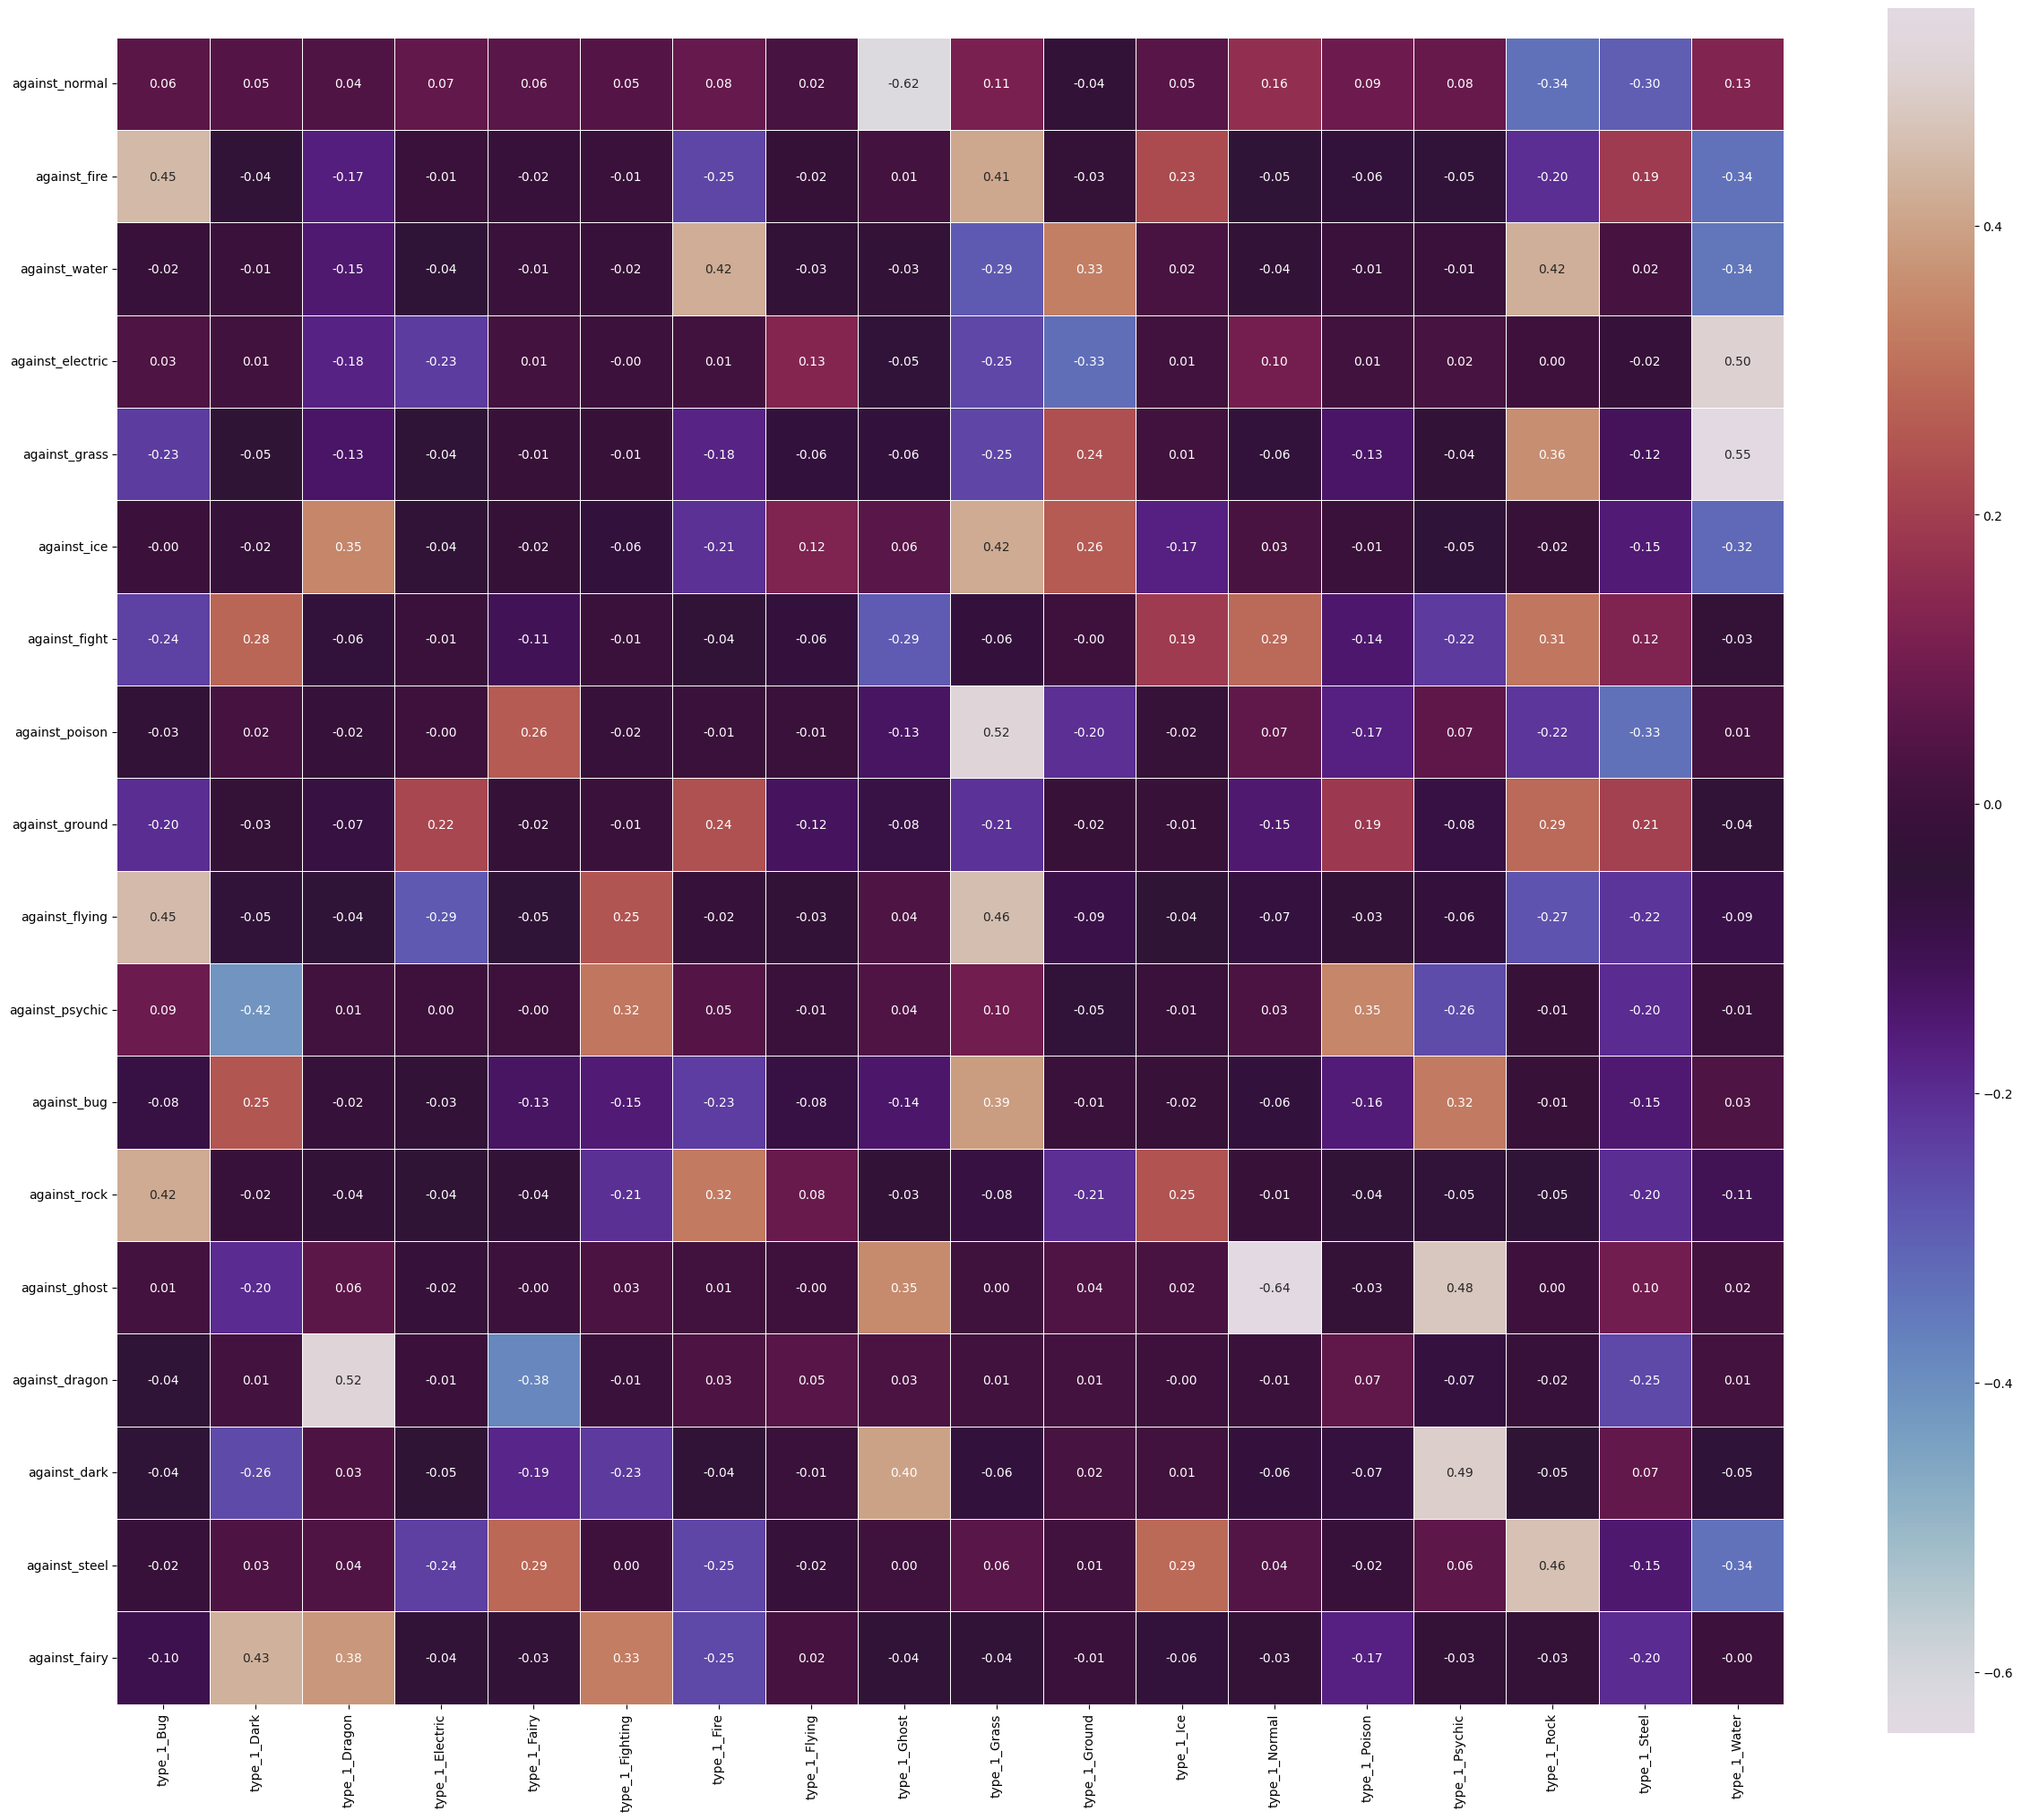

In [953]:

type_one_hot = pd.get_dummies(df['type_1'], prefix='type_1')
against_columns = df.filter(like='against_').columns
results = {}

for type_col in type_one_hot.columns:
    temp_df = df.copy()
    temp_df[type_col] = type_one_hot[type_col]
    
    correlations = temp_df[against_columns].corrwith(temp_df[type_col])
    results[type_col] = correlations

correlation_results = pd.DataFrame(results)

plt.figure(figsize=(30, 25))
sns.heatmap(correlation_results, annot=True, fmt=".2f", cmap='twilight', square=True, cbar=True, linewidths=.5)


**Вывод**

Точных выводов по взаимосвязи сделать нельзя, поскольку существует прямая зависимость между количеством урона против покемонов, определенного вида, от вида самого покемона. Есть случаи. когда у покемонов повышен урон против других покемонов такого же основного типа, а также прямая и обратная зависимость между двумя покемонами разного основного типа.

In [954]:
# sns.pairplot(df, hue='status')

In [955]:
missing_data = df.isnull().sum()
exclude_columns = ['type_2', 'ability_2', 'ability_hidden', 'egg_type_2', 'percentage_male']
missing_data = df.drop(columns=exclude_columns).isnull().sum()
missing_data[missing_data > 0]

german_name         90
japanese_name       90
weight_kg            1
ability_1            3
catch_rate         104
base_friendship    104
base_experience    104
growth_rate          1
egg_type_1           3
egg_cycles           1
dtype: int64

In [956]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)    
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Пропущенных значений', 1 : '% от общего количества'})

    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    '% от общего количества', ascending=False).round(1)

    
    print ("В датасете " + str(df.shape[1]) + " колонок.\n"      
        "В " + str(mis_val_table_ren_columns.shape[0]) +
          " колoнках есть пропущенные значения.")

    return mis_val_table_ren_columns

In [957]:
train_missing = missing_values_table(df)
train_missing

В датасете 51 колонок.
В 15 колoнках есть пропущенные значения.


,Пропущенных значений,% от общего количества
egg_type_2,746,72.6
ability_2,515,50.1
type_2,486,47.3
percentage_male,236,23.0
ability_hidden,218,21.2
catch_rate,104,10.1
base_friendship,104,10.1
base_experience,104,10.1
german_name,90,8.8
japanese_name,90,8.8


**Работа с графиками** 

Определение недостающих данных.

<Axes: >

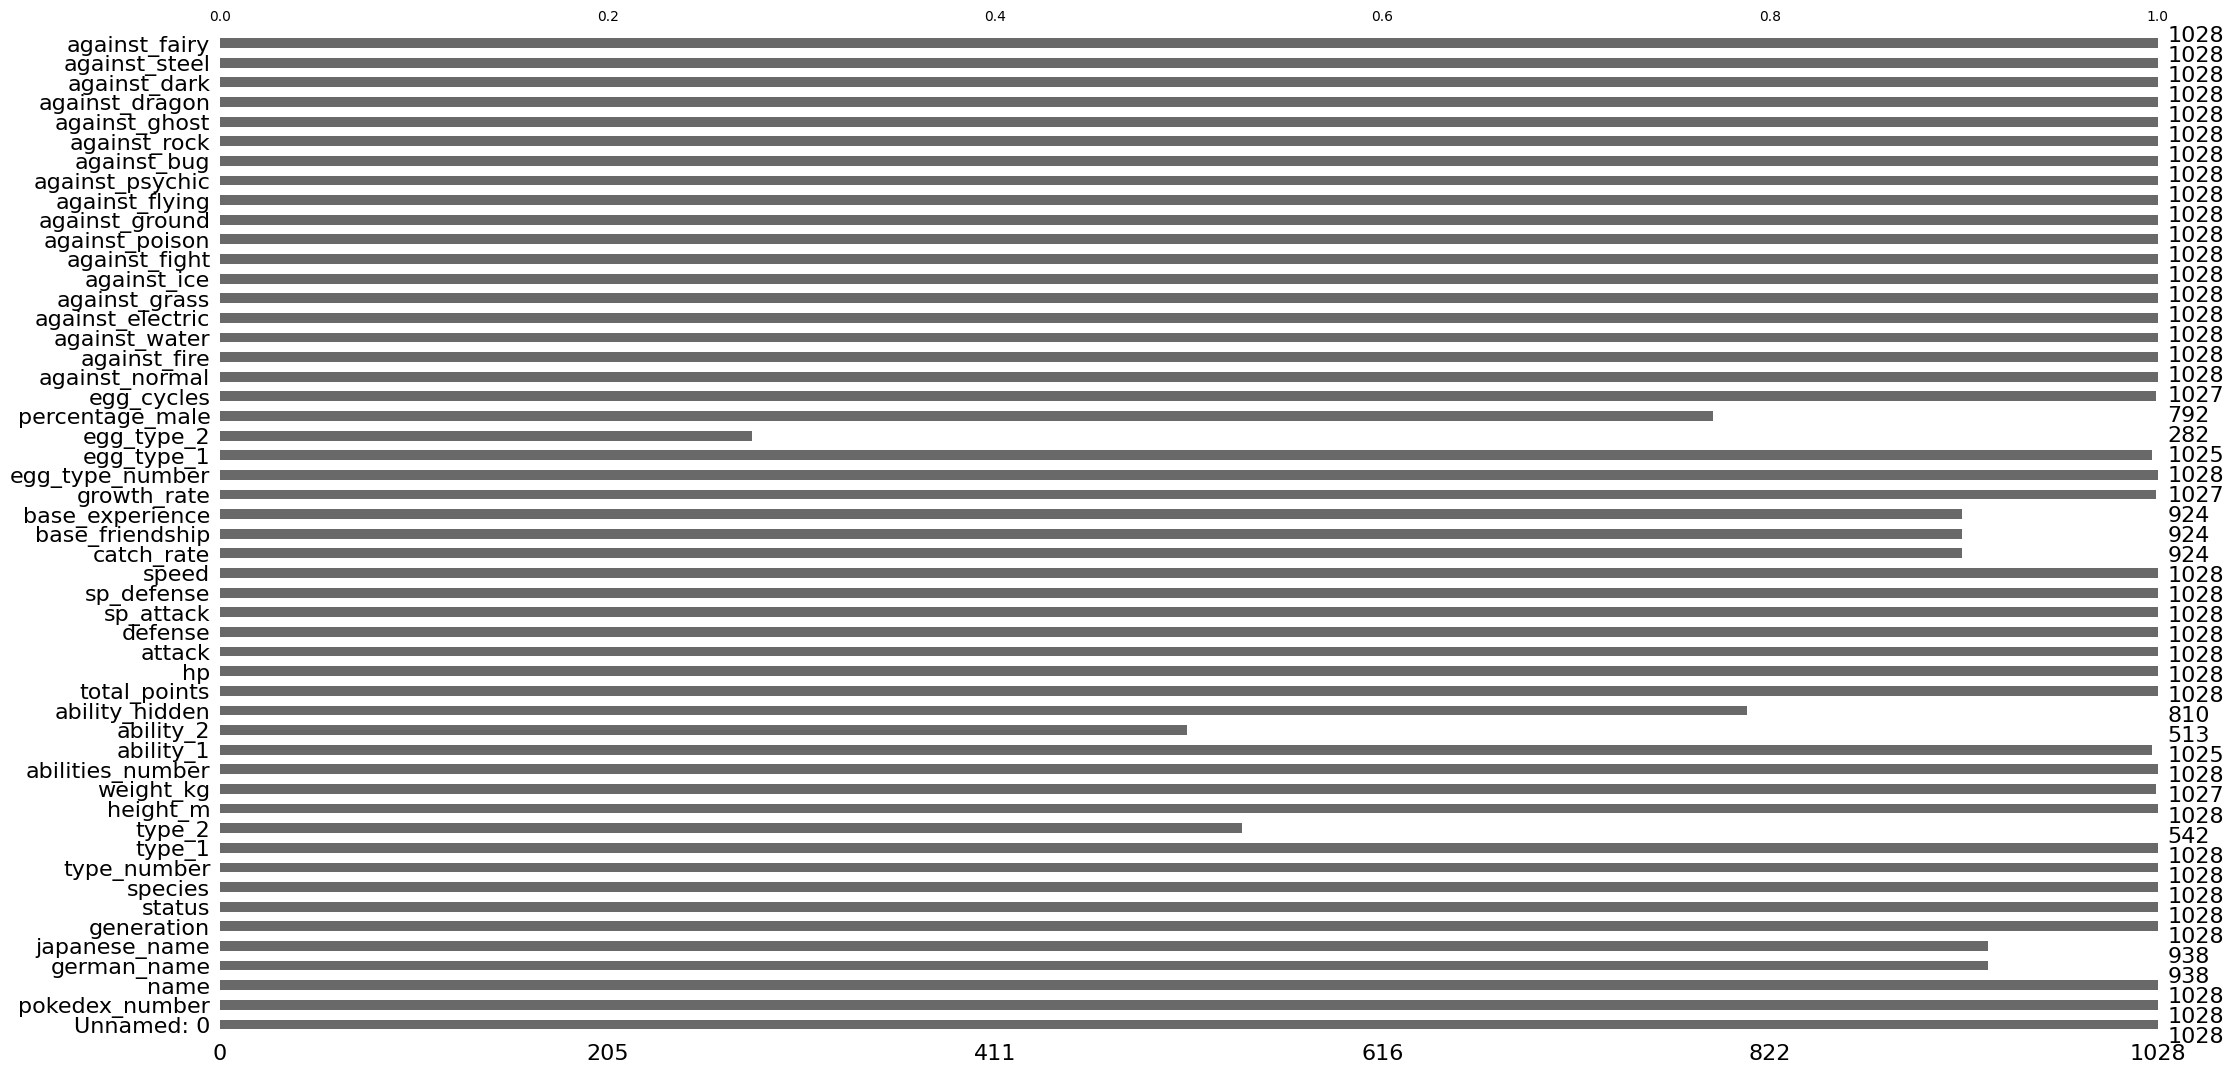

In [958]:
msno.bar(df)

**ВЫВОД**

Больше потерянных данных имеют показатели egg_type_2 - вторая группа яиц,  ability_2 - вторая способность, type_2 - вторичный тип покемона. По всем трем категориям, в свете их особенностей можно сделать вывод, что у данных покемонов просто отсутствует вторая группа яиц, либо вторая способность, либо вторичный тип покемона.
 

**МЕСТОПОЛОЖЕНИЕ НЕДОСТАЮЩИХ ДАННЫХ**

<Axes: >

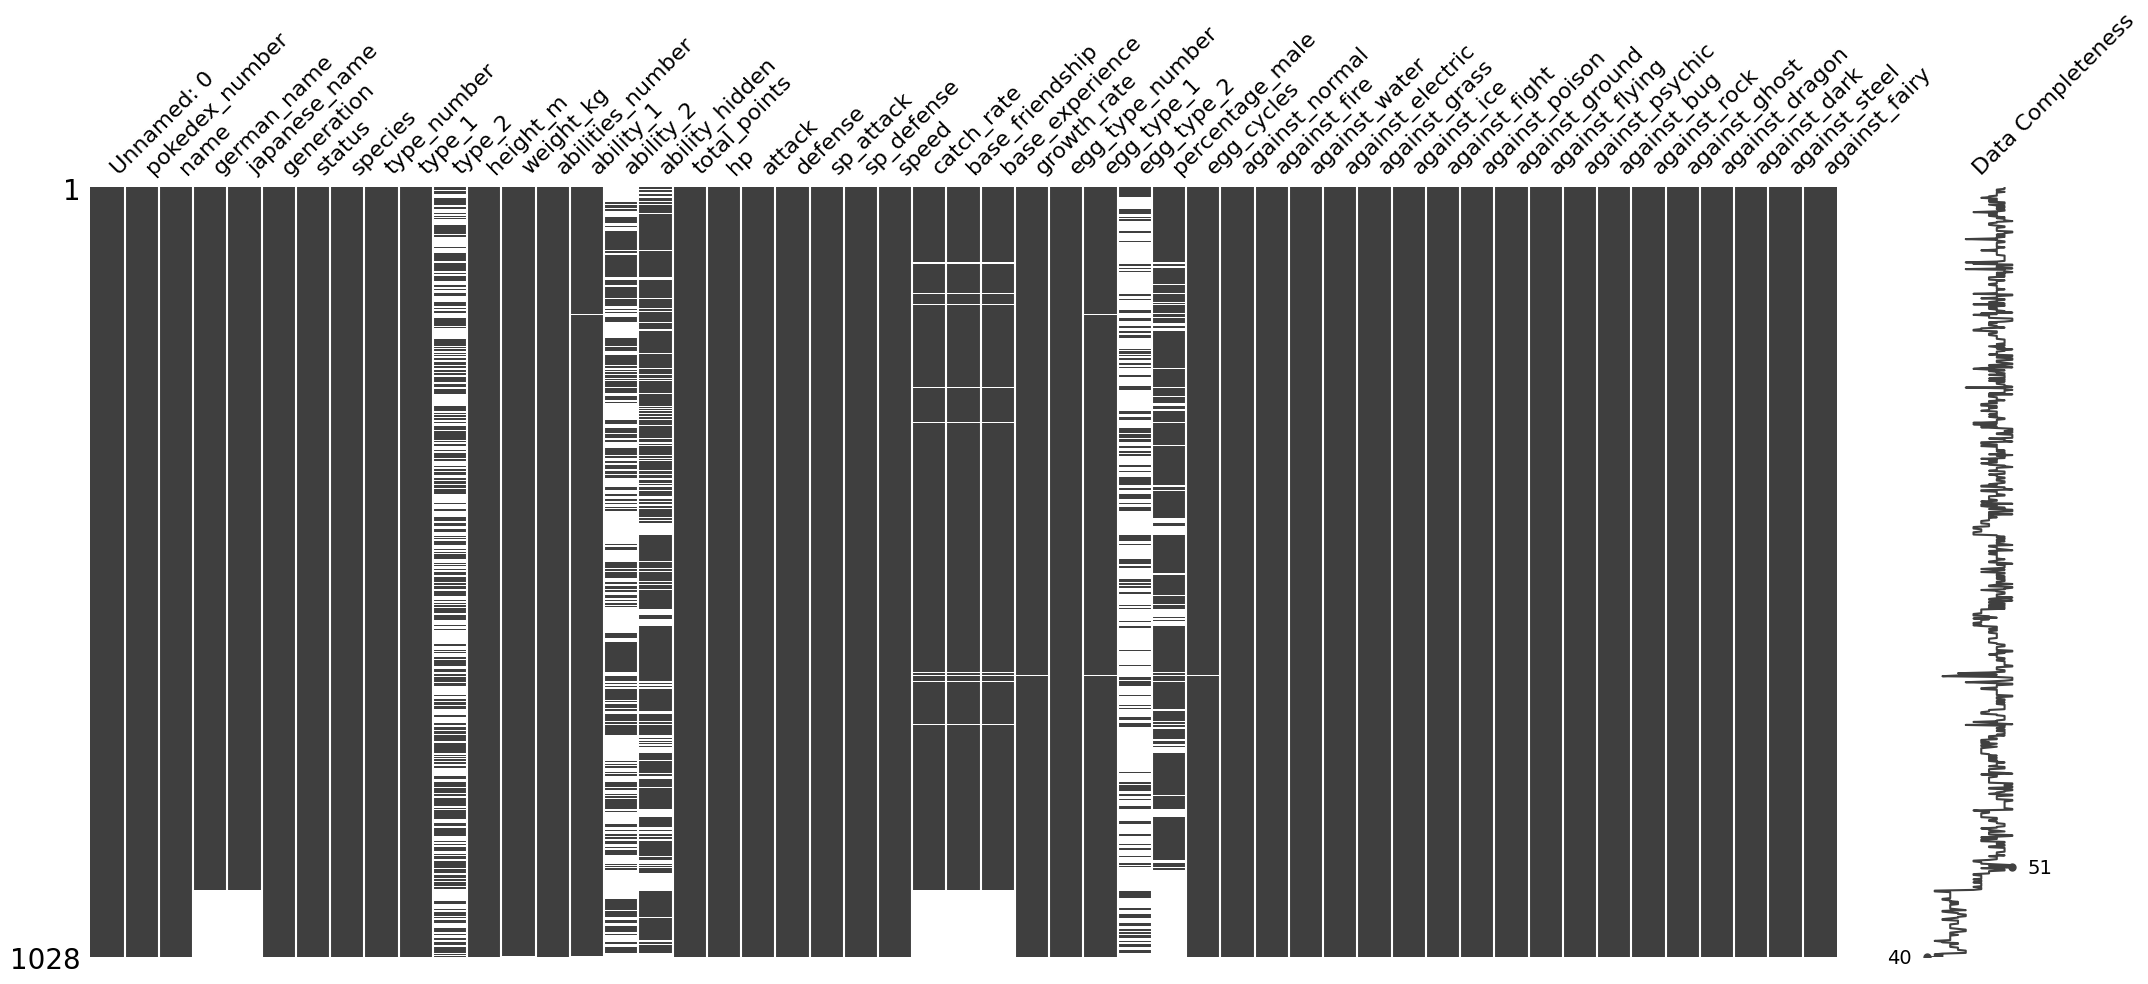

In [959]:
msno.matrix(df, labels=True)

**Вывод**

Имеем 38 полных столбца из 51.

Количество пропущенных строк большое у данных, в столбцах german_name, japanese_name, type_2, ability_2, ability_hidden, catch_rate, base_friendship, base_experience, egg_type_2, percentage_male.

**ДАЛЕЕ** нужно извлечь подвыборку из всего набора данных, чтобы определить точное местоположение пропущенных значений.

<Axes: >

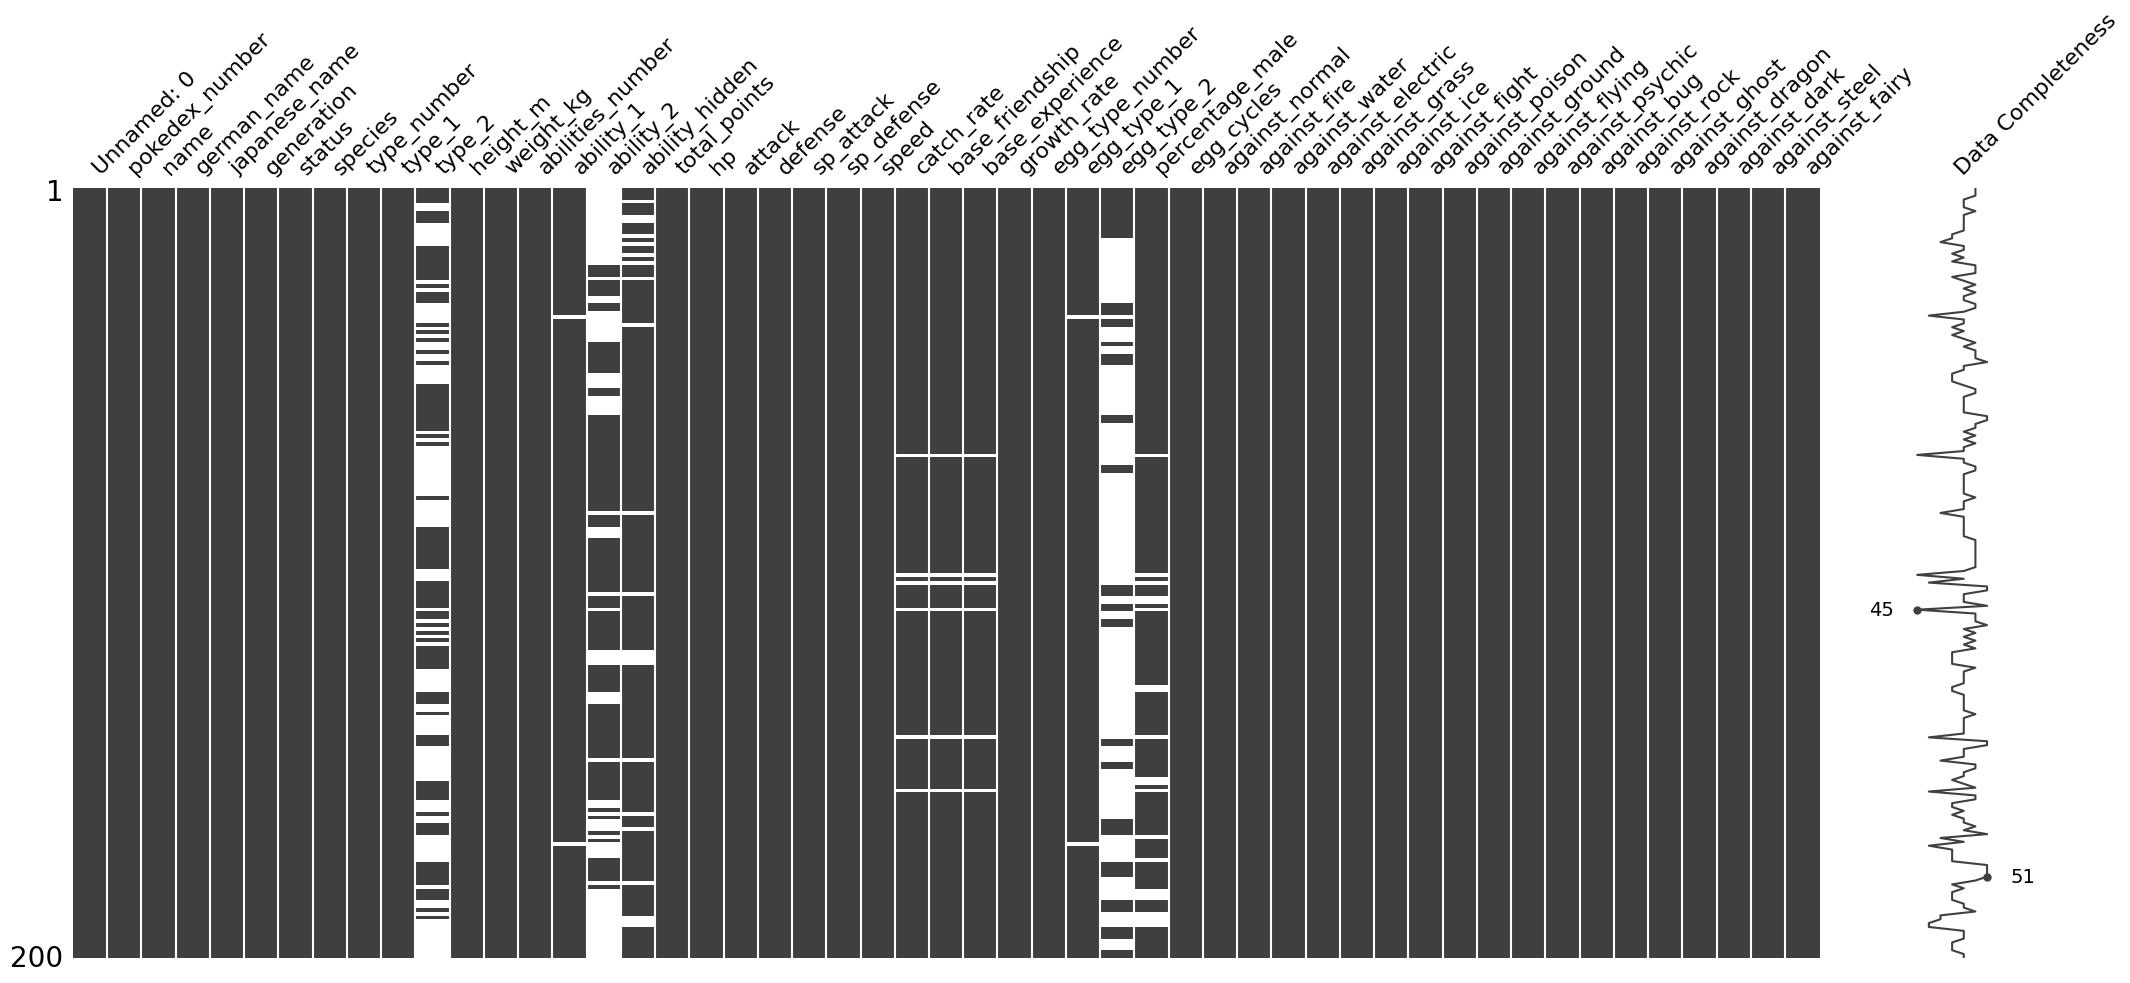

In [960]:
msno.matrix(df.head(200), labels=True)

* Столбец __ability_1 и type_1__ имеет очень мало пропущенных значений, и, похоже, он не коррелирует с любым другим столбцом. Следовательно, пропуск в столбце __ability_1 и type_1__ можно отнести к категории «Отсутствуют полностью случайно».


* В столбцах __base_experience, base_friendship, catch_rate__ одновременно стоят пропущенные значения. Это может быть случай MAR, поскольку мы не можем напрямую определить причину отсутствия данных в этих столбцах.

`missingno` также позволяет нам отсортировать график по определенному столбцу. Давайте отсортируем значения.


<Axes: >

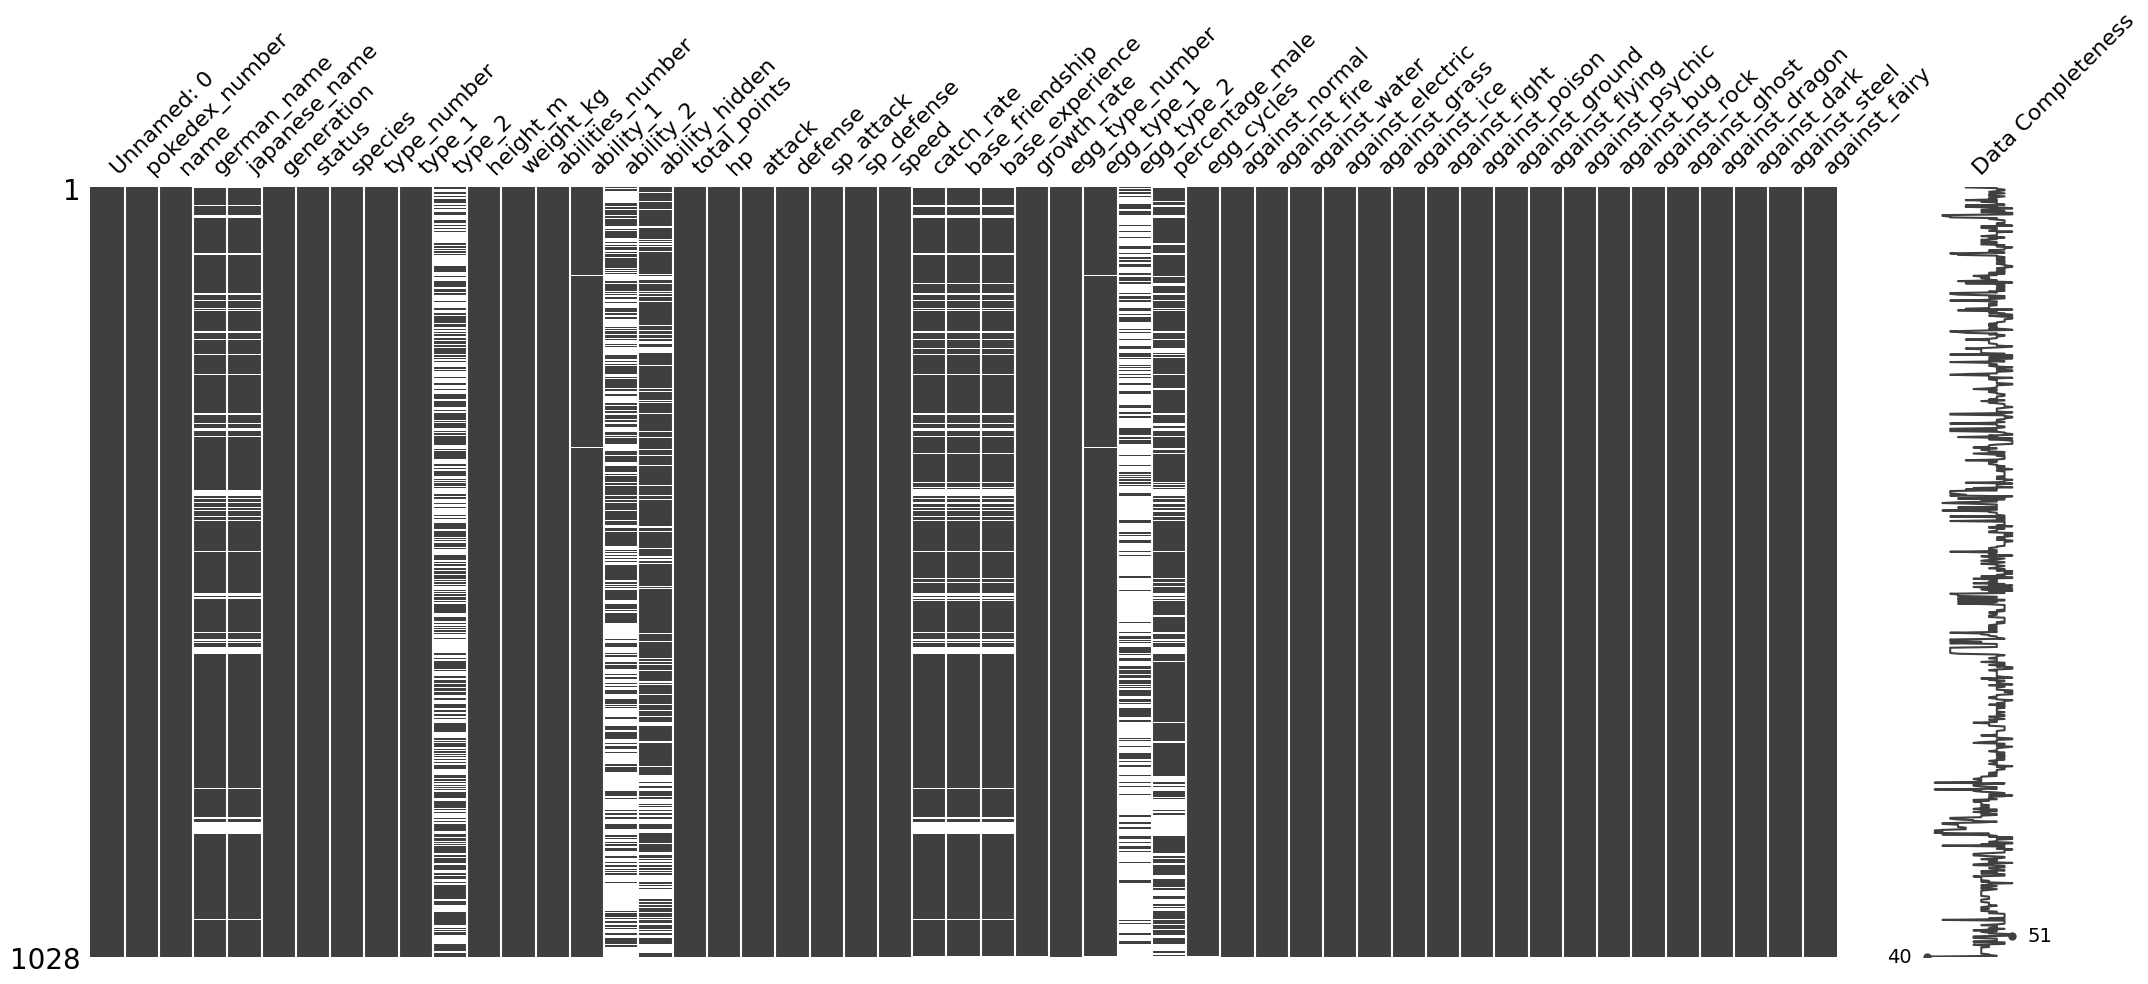

In [961]:
sorted = df.sort_values('growth_rate')
msno.matrix(sorted, labels=True)

**ВЫВОД**

По данным графика мы можем сделать вывод о том, что присутствует зависимость пропусков в столбцах с base_experience, base_friendship, catch_rate.

Построим матрицу:

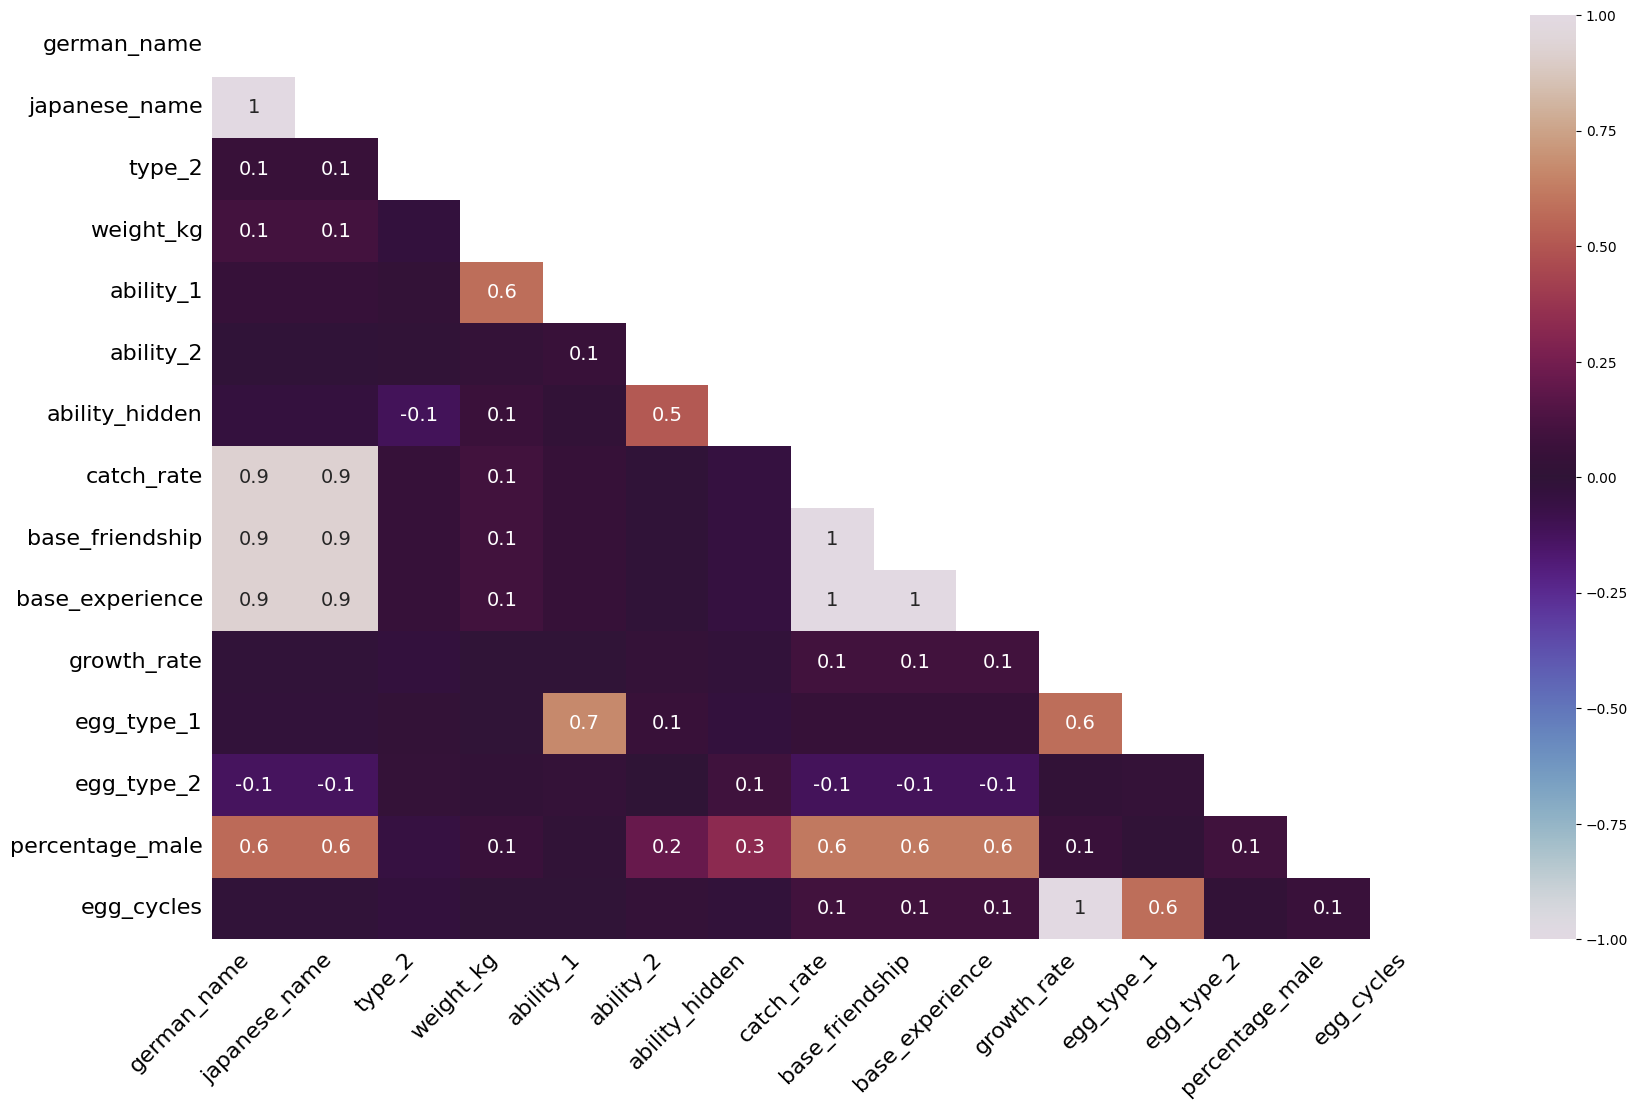

In [962]:
msno.heatmap(df, cmap='twilight');

**ВЫВОД** 

Наблюдается корреляция между наблюдаемыми столбцами - относим данные к типу MNAR (Missing Not at Random) - Неслучайные пропуски. Возможно, пропуски связаны с тем, что для данных покемонов было тяжело зафиксировать данные по этим признакам. 

**Удаляем данные** корреляций 0.9-1 

In [963]:
column_to_droping = ['german_name', 'japanese_name',  'catch_rate', 'base_experience', 'base_friendship']
df.drop(column_to_droping, axis=1, inplace=True)

In [964]:
df

,Unnamed: 0,pokedex_number,name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,0,1,Bulbasaur,1,Normal,Seed Pokémon,2,Grass,Poison,0.7,6.9,2,Overgrow,NaN,Chlorophyll,318.0,45.0,49.0,49.0,65.0,65.0,45.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
1,1,2,Ivysaur,1,Normal,Seed Pokémon,2,Grass,Poison,1.0,13.0,2,Overgrow,NaN,Chlorophyll,405.0,60.0,62.0,63.0,80.0,80.0,60.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
2,2,3,Venusaur,1,Normal,Seed Pokémon,2,Grass,Poison,2.0,100.0,2,Overgrow,NaN,Chlorophyll,525.0,80.0,82.0,83.0,100.0,100.0,80.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
3,3,3,Mega Venusaur,1,Normal,Seed Pokémon,2,Grass,Poison,2.4,155.5,1,Thick Fat,NaN,NaN,625.0,80.0,100.0,123.0,122.0,120.0,80.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,1.0,0.5,0.5,0.25,1.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
4,4,4,Charmander,1,Normal,Lizard Pokémon,1,Fire,NaN,0.6,8.5,2,Blaze,NaN,Solar Power,309.0,39.0,52.0,43.0,60.0,50.0,65.0,Medium Slow,2,Dragon,Monster,87.5,20.0,1.0,0.5,2.0,1.0,0.50,0.5,1.0,1.0,2.0,1.0,1.0,0.50,2.00,1.0,1.0,1.0,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,1023,888,Zacian Hero of Many Battles,8,Legendary,Warrior Pokémon,1,Fairy,NaN,2.8,110.0,1,Intrepid Sword,NaN,NaN,670.0,92.0,130.0,115.0,80.0,115.0,138.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,1.0,1.0,1.0,1.00,1.0,0.5,2.0,1.0,1.0,1.0,0.50,1.00,1.0,0.0,0.5,2.0,1.0
1024,1024,889,Zamazenta Crowned Shield,8,Legendary,Warrior Pokémon,2,Fighting,Steel,2.9,785.0,1,Dauntless Shield,NaN,NaN,720.0,92.0,130.0,145.0,80.0,145.0,128.0,Slow,1,Undiscovered,NaN,NaN,120.0,0.5,2.0,1.0,1.0,0.50,0.5,2.0,0.0,2.0,1.0,1.0,0.25,0.25,1.0,0.5,0.5,0.5,1.0
1025,1025,889,Zamazenta Hero of Many Battles,8,Legendary,Warrior Pokémon,1,Fighting,NaN,2.9,210.0,1,Dauntless Shield,NaN,NaN,670.0,92.0,130.0,115.0,80.0,115.0,138.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.0,2.0,2.0,0.50,0.50,1.0,1.0,0.5,1.0,2.0
1026,1026,890,Eternatus,8,Legendary,Gigantic Pokémon,2,Poison,Dragon,20.0,950.0,1,Pressure,NaN,NaN,690.0,140.0,85.0,95.0,145.0,95.0,130.0,Slow,1,Undiscovered,NaN,NaN,120.0,1.0,0.5,0.5,0.5,0.25,2.0,0.5,0.5,2.0,1.0,2.0,0.50,1.00,1.0,2.0,1.0,1.0,1.0


In [965]:
df.isnull().sum()

Unnamed: 0            0
pokedex_number        0
name                  0
generation            0
status                0
species               0
type_number           0
type_1                0
type_2              486
height_m              0
weight_kg             1
abilities_number      0
ability_1             3
ability_2           515
ability_hidden      218
total_points          0
hp                    0
attack                0
defense               0
sp_attack             0
sp_defense            0
speed                 0
growth_rate           1
egg_type_number       0
egg_type_1            3
egg_type_2          746
percentage_male     236
egg_cycles            1
against_normal        0
against_fire          0
against_water         0
against_electric      0
against_grass         0
against_ice           0
against_fight         0
against_poison        0
against_ground        0
against_flying        0
against_psychic       0
against_bug           0
against_rock          0
against_ghost   

In [966]:
missing_data = df.isnull().sum()
missing_data[missing_data > 0]

type_2             486
weight_kg            1
ability_1            3
ability_2          515
ability_hidden     218
growth_rate          1
egg_type_1           3
egg_type_2         746
percentage_male    236
egg_cycles           1
dtype: int64

Пропуски в столбцах type_2, ability_2, ability_hidden, egg_type_2, percentage_male имеет информативное значение - наличие пропусков в данных признаках приравнивается отсутсвию у покемона вторичного типа, второй способности, скрытой способности, второй группы яиц, пола. Для удобства работы с данными заменяем пропуски на 0

In [967]:
df[['type_2', 'ability_2', 'ability_hidden', 'egg_type_2', 'percentage_male']] = df[['type_2', 'ability_2', 'ability_hidden', 'egg_type_2', 'percentage_male']].fillna(value='0')
df

,Unnamed: 0,pokedex_number,name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,0,1,Bulbasaur,1,Normal,Seed Pokémon,2,Grass,Poison,0.7,6.9,2,Overgrow,0,Chlorophyll,318.0,45.0,49.0,49.0,65.0,65.0,45.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
1,1,2,Ivysaur,1,Normal,Seed Pokémon,2,Grass,Poison,1.0,13.0,2,Overgrow,0,Chlorophyll,405.0,60.0,62.0,63.0,80.0,80.0,60.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
2,2,3,Venusaur,1,Normal,Seed Pokémon,2,Grass,Poison,2.0,100.0,2,Overgrow,0,Chlorophyll,525.0,80.0,82.0,83.0,100.0,100.0,80.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
3,3,3,Mega Venusaur,1,Normal,Seed Pokémon,2,Grass,Poison,2.4,155.5,1,Thick Fat,0,0,625.0,80.0,100.0,123.0,122.0,120.0,80.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,1.0,0.5,0.5,0.25,1.0,0.5,1.0,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
4,4,4,Charmander,1,Normal,Lizard Pokémon,1,Fire,0,0.6,8.5,2,Blaze,0,Solar Power,309.0,39.0,52.0,43.0,60.0,50.0,65.0,Medium Slow,2,Dragon,Monster,87.5,20.0,1.0,0.5,2.0,1.0,0.50,0.5,1.0,1.0,2.0,1.0,1.0,0.50,2.00,1.0,1.0,1.0,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,1023,888,Zacian Hero of Many Battles,8,Legendary,Warrior Pokémon,1,Fairy,0,2.8,110.0,1,Intrepid Sword,0,0,670.0,92.0,130.0,115.0,80.0,115.0,138.0,Slow,1,Undiscovered,0,0,120.0,1.0,1.0,1.0,1.0,1.00,1.0,0.5,2.0,1.0,1.0,1.0,0.50,1.00,1.0,0.0,0.5,2.0,1.0
1024,1024,889,Zamazenta Crowned Shield,8,Legendary,Warrior Pokémon,2,Fighting,Steel,2.9,785.0,1,Dauntless Shield,0,0,720.0,92.0,130.0,145.0,80.0,145.0,128.0,Slow,1,Undiscovered,0,0,120.0,0.5,2.0,1.0,1.0,0.50,0.5,2.0,0.0,2.0,1.0,1.0,0.25,0.25,1.0,0.5,0.5,0.5,1.0
1025,1025,889,Zamazenta Hero of Many Battles,8,Legendary,Warrior Pokémon,1,Fighting,0,2.9,210.0,1,Dauntless Shield,0,0,670.0,92.0,130.0,115.0,80.0,115.0,138.0,Slow,1,Undiscovered,0,0,120.0,1.0,1.0,1.0,1.0,1.00,1.0,1.0,1.0,1.0,2.0,2.0,0.50,0.50,1.0,1.0,0.5,1.0,2.0
1026,1026,890,Eternatus,8,Legendary,Gigantic Pokémon,2,Poison,Dragon,20.0,950.0,1,Pressure,0,0,690.0,140.0,85.0,95.0,145.0,95.0,130.0,Slow,1,Undiscovered,0,0,120.0,1.0,0.5,0.5,0.5,0.25,2.0,0.5,0.5,2.0,1.0,2.0,0.50,1.00,1.0,2.0,1.0,1.0,1.0


In [968]:
df.isnull().sum()

Unnamed: 0          0
pokedex_number      0
name                0
generation          0
status              0
species             0
type_number         0
type_1              0
type_2              0
height_m            0
weight_kg           1
abilities_number    0
ability_1           3
ability_2           0
ability_hidden      0
total_points        0
hp                  0
attack              0
defense             0
sp_attack           0
sp_defense          0
speed               0
growth_rate         1
egg_type_number     0
egg_type_1          3
egg_type_2          0
percentage_male     0
egg_cycles          1
against_normal      0
against_fire        0
against_water       0
against_electric    0
against_grass       0
against_ice         0
against_fight       0
against_poison      0
against_ground      0
against_flying      0
against_psychic     0
against_bug         0
against_rock        0
against_ghost       0
against_dragon      0
against_dark        0
against_steel       0
against_fa

In [969]:
missing_data = df.isnull().sum()
missing_data[missing_data > 0]

weight_kg      1
ability_1      3
growth_rate    1
egg_type_1     3
egg_cycles     1
dtype: int64

**Заполняем пропуски**

В количественных данных используем **mean**

In [970]:
df_cleaned = df

In [971]:
df_cleaned['weight_kg'].fillna(df_cleaned['weight_kg'].mean(), inplace=True)

В категориальных данных используем **mode**

In [972]:
categorical_cols = list(df.select_dtypes(include=['object']).columns)
df[categorical_cols].isna().sum()

name               0
status             0
species            0
type_1             0
type_2             0
ability_1          3
ability_2          0
ability_hidden     0
growth_rate        1
egg_type_1         3
egg_type_2         0
percentage_male    0
dtype: int64

In [973]:
for col in categorical_cols:
    mode_col = df[col].mode()[0]
    df[col].fillna(mode_col, inplace=True)
    

In [974]:
df[categorical_cols].isna().sum()

name               0
status             0
species            0
type_1             0
type_2             0
ability_1          0
ability_2          0
ability_hidden     0
growth_rate        0
egg_type_1         0
egg_type_2         0
percentage_male    0
dtype: int64

In [975]:
df_cleaned.isnull().sum()

Unnamed: 0          0
pokedex_number      0
name                0
generation          0
status              0
species             0
type_number         0
type_1              0
type_2              0
height_m            0
weight_kg           0
abilities_number    0
ability_1           0
ability_2           0
ability_hidden      0
total_points        0
hp                  0
attack              0
defense             0
sp_attack           0
sp_defense          0
speed               0
growth_rate         0
egg_type_number     0
egg_type_1          0
egg_type_2          0
percentage_male     0
egg_cycles          1
against_normal      0
against_fire        0
against_water       0
against_electric    0
against_grass       0
against_ice         0
against_fight       0
against_poison      0
against_ground      0
against_flying      0
against_psychic     0
against_bug         0
against_rock        0
against_ghost       0
against_dragon      0
against_dark        0
against_steel       0
against_fa

In [976]:
missing_data = df.isnull().sum()

missing_data[missing_data > 0]

egg_cycles    1
dtype: int64

In [977]:
df = df_cleaned

In [978]:
mode_a = df['growth_rate'].mode()[0]  # Получаем самое частое значение
df['growth_rate'] = df['growth_rate'].fillna(mode_a)

In [979]:
df['percentage_male'] = df['percentage_male'].fillna(0)

Все пропуски в датасете были заполнены

In [980]:
df.head(5)

,Unnamed: 0,pokedex_number,name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,abilities_number,ability_1,ability_2,ability_hidden,total_points,hp,attack,defense,sp_attack,sp_defense,speed,growth_rate,egg_type_number,egg_type_1,egg_type_2,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,0,1,Bulbasaur,1,Normal,Seed Pokémon,2,Grass,Poison,0.7,6.9,2,Overgrow,0,Chlorophyll,318.0,45.0,49.0,49.0,65.0,65.0,45.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
1,1,2,Ivysaur,1,Normal,Seed Pokémon,2,Grass,Poison,1.0,13.0,2,Overgrow,0,Chlorophyll,405.0,60.0,62.0,63.0,80.0,80.0,60.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
2,2,3,Venusaur,1,Normal,Seed Pokémon,2,Grass,Poison,2.0,100.0,2,Overgrow,0,Chlorophyll,525.0,80.0,82.0,83.0,100.0,100.0,80.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,2.0,0.5,0.5,0.25,2.0,0.5,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
3,3,3,Mega Venusaur,1,Normal,Seed Pokémon,2,Grass,Poison,2.4,155.5,1,Thick Fat,0,0,625.0,80.0,100.0,123.0,122.0,120.0,80.0,Medium Slow,2,Grass,Monster,87.5,20.0,1.0,1.0,0.5,0.5,0.25,1.0,0.5,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5
4,4,4,Charmander,1,Normal,Lizard Pokémon,1,Fire,0,0.6,8.5,2,Blaze,0,Solar Power,309.0,39.0,52.0,43.0,60.0,50.0,65.0,Medium Slow,2,Dragon,Monster,87.5,20.0,1.0,0.5,2.0,1.0,0.50,0.5,1.0,1.0,2.0,1.0,1.0,0.5,2.0,1.0,1.0,1.0,0.5,0.5


**Выбросы**

Ранее были рассмотрены графики ящик с усами (boxplot) показателей total_points, attack, hp, defense, speed, на которых явно визуально видны выбросы.

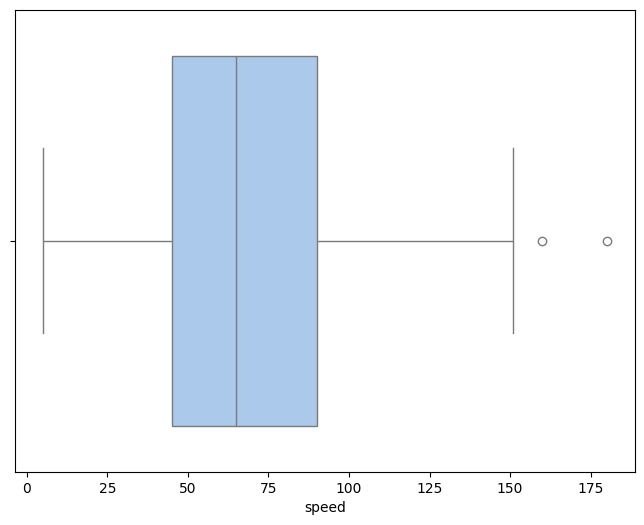

In [981]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['speed'])
plt.show()

На графике ящика с усами признака speed видны два выброса. Работаем с ним с помощью тримминга

In [982]:
df['speed'].describe()

count    1028.000000
mean       68.534047
std        29.802103
min         5.000000
25%        45.000000
50%        65.000000
75%        90.000000
max       180.000000
Name: speed, dtype: float64

In [983]:
Q1 = df['speed'].quantile(0.25)
Q3 = df['speed'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [984]:
df_speed_new = df[(df["speed"] > lower_bound) & (df["speed"] < upper_bound)]

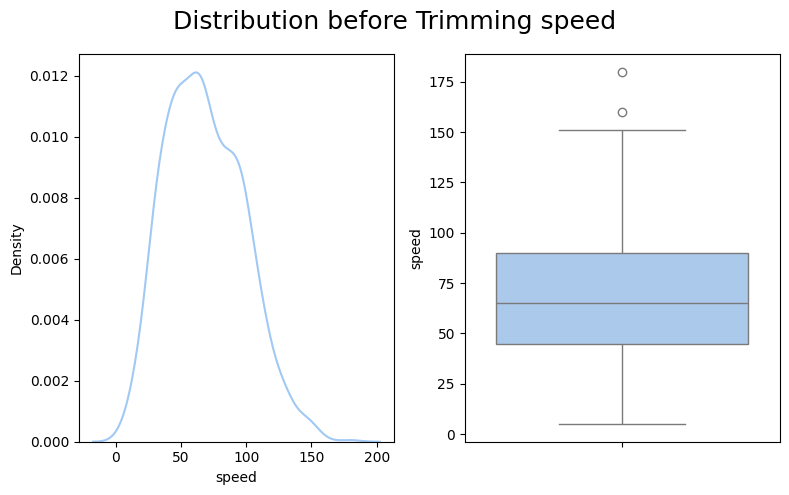

In [985]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution before Trimming speed", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df['speed'])
plt.subplot(1,2,2)
sns.boxplot(data = df['speed'])
plt.tight_layout()
plt.show()

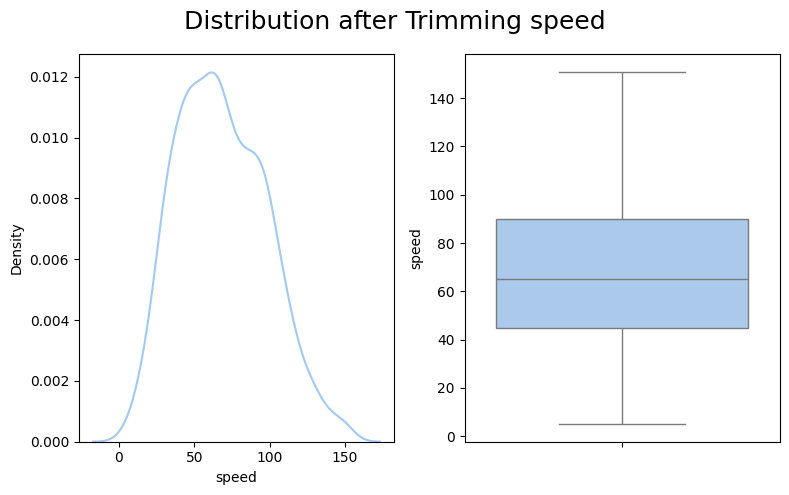

In [986]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution after Trimming speed", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_speed_new['speed'])
plt.subplot(1,2,2)
sns.boxplot(data = df_speed_new['speed'])
plt.tight_layout()
plt.show()

In [987]:
df_speed_new.shape

(1026, 46)

Поскольку строки в датасете ограничены, было возможно удалить выбросы при устранении двух строк. Но для сохранения целостности и качества датасета стоит использовать кэппинг

In [988]:
q1 = df["weight_kg"].quantile(0.25)
q2 = df["weight_kg"].quantile(0.75)
IQR = q2 - q1
max_limit = q2 + (1.5 * IQR)
min_limit = q1 - (1.5 * IQR) 

In [989]:
df_weight_kg_new = pd.DataFrame(np.where(df["weight_kg"] > max_limit, max_limit, 
         (np.where(df["weight_kg"] < min_limit, min_limit, df["weight_kg"]))), columns=["weight_kg"])

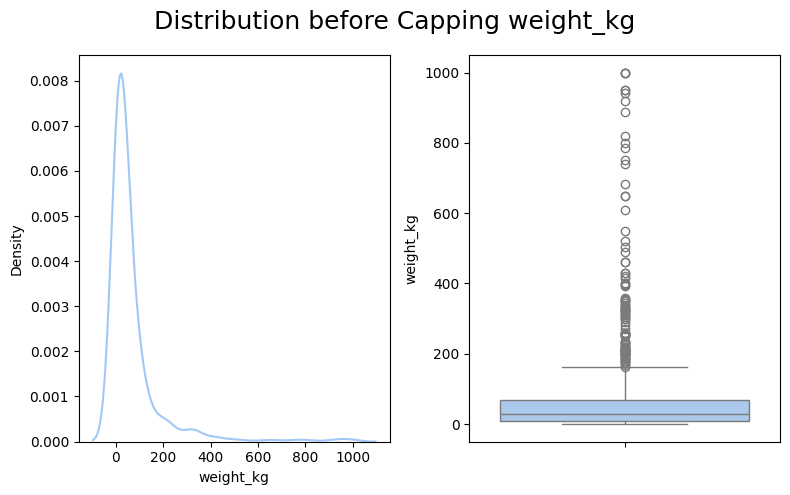

In [990]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution before Capping weight_kg", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df['weight_kg'])
plt.subplot(1,2,2)
sns.boxplot(data = df['weight_kg'])
plt.tight_layout()
plt.show()

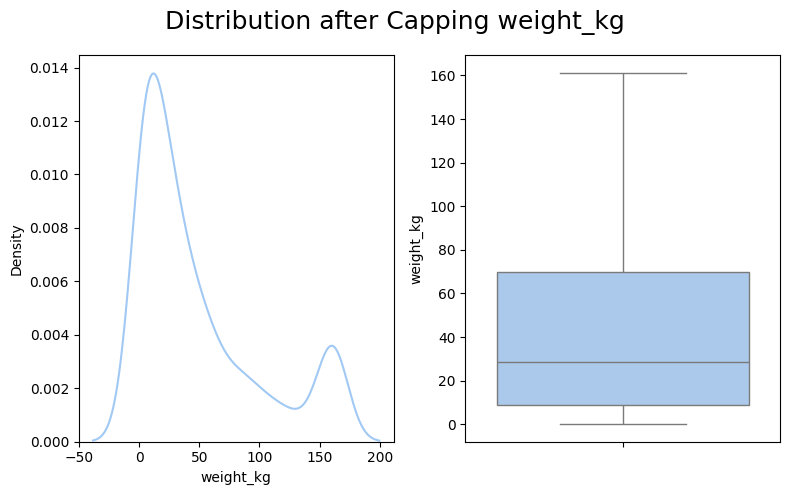

In [991]:
plt.figure(figsize=(8,5))
plt.suptitle("Distribution after Capping weight_kg", fontsize=18)
plt.subplot(1,2,1)
sns.kdeplot(data = df_weight_kg_new['weight_kg'])
plt.subplot(1,2,2)
sns.boxplot(data = df_weight_kg_new['weight_kg'])
plt.tight_layout()
plt.show()

In [992]:
df_weight_kg_new.shape

(1028, 1)

Вес покемонов отличается асимметричным распределениями - скошенное вправо (positive skewness). Объяснить подобные выбросы для **веса покемонов** (как и роста) можно следующим образом:

   - Распределение веса (или роста) покемонов может являться скосным вправо из-за наличия сложностей при фиксации более высоких значений, поскольку часто всплывает фактор страха размера покемона или же ошибки из-за примерной оценки сильно превышающих размером человека покемонов.

По большей части выбросы не стоит убирать, поскольку они являются уникальной частью каждого покемона, добавляющие им специфичные характеристики.

**Выбор метрики - F1 score**

Целевая переменная status распределена неравномерно, поэтому следует использовать F1

Micro F1 хуже работает на несбалансированных наборах данных, чем средняя оценка macro F1. Причина этого в том, что micro F1 придает равное значение каждому наблюдению, в то время как macro F1 придает каждому классу равное значение

Берем Fmicro потому что для данного параметра важны минорные классы, а нам интересны именно они.



In [993]:
df.describe(include="object")

,name,status,species,type_1,type_2,ability_1,ability_2,ability_hidden,growth_rate,egg_type_1,egg_type_2,percentage_male
count,1028,1028,1028,1028,1028,1028,1028,1028,1028,1028,1028,1028.0
unique,1028,4,641,18,19,202,127,155,6,15,12,7.0
top,Bulbasaur,Normal,Mouse Pokémon,Water,0,Levitate,0,0,Medium Fast,Field,0,50.0
freq,1,915,12,134,486,44,515,218,433,261,746,564.0


# Перекодировка категориальных столбцов

In [994]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

Используем метод **Label Encoding** для столбцов **growth_rate**, т.к. признаки являются ординальными.

In [995]:
df["growth_rate"].unique()

array(['Medium Slow', 'Medium Fast', 'Fast', 'Slow', 'Fluctuating',
       'Erratic'], dtype=object)

In [996]:
le = LabelEncoder()
a = le.fit_transform(df['growth_rate'])
a

array([4, 4, 4, ..., 5, 5, 5])

Даем каждому значению признака скорость_роста от наихудшего к наилучшему

- "Fluctuating" - 0
- 'Erratic' - 0
- "Slow" - 1
- "Medium Slow" - 2
- "Medium Fast" - 3
- "Fast" - 4

In [997]:
m = {"Fluctuating": 0,'Erratic': 0, "Slow": 1, "Medium Slow": 2, "Medium Fast": 3, "Fast": 4}

In [998]:
df['growth_rate_n'] = df['growth_rate'].map(m)
le = LabelEncoder()
df['growth_rate'] = le.fit_transform(df['growth_rate_n'])
le.fit_transform(df['growth_rate_n'])

array([2, 2, 2, ..., 1, 1, 1], dtype=int64)

In [999]:
df['growth_rate_n'].unique()

array([2, 3, 4, 1, 0], dtype=int64)

**species, type_1, type_2, ability_1, ability_2, ability_hidden, egg_type_1, egg_type_2** перекодировка методом **Frequency** 

In [1000]:
species_freq = df['species'].value_counts(normalize=True)
type_1_freq = df['type_1'].value_counts(normalize=True)
type_2_freq = df['type_2'].value_counts(normalize=True)
ability_1_freq = df['ability_1'].value_counts(normalize=True)
ability_2_freq = df['ability_2'].value_counts(normalize=True)
ability_hidden_freq = df['ability_hidden'].value_counts(normalize=True)
egg_type_1_freq = df['egg_type_1'].value_counts(normalize=True)
egg_type_2_freq = df['egg_type_2'].value_counts(normalize=True)

In [1001]:
df['1en'] = df['species'].map(species_freq)
df['2en'] = df['type_1'].map(type_1_freq)
df['3en'] = df['type_2'].map(type_2_freq)
df['4en'] = df['ability_1'].map(ability_1_freq)
df['5en'] = df['ability_2'].map(ability_2_freq)
df['6en'] = df['ability_hidden'].map(ability_hidden_freq)
df['7en'] = df['egg_type_1'].map(egg_type_1_freq)
df['8en'] = df['egg_type_2'].map(egg_type_2_freq)

In [1002]:
df[['species', '1en']].sample(5)

,species,1en
68,Scratch Cat Pokémon,0.002918
685,Sky Squirrel Pokémon,0.000973
462,DNA Pokémon,0.003891
680,Fresh Snow Pokémon,0.001946
505,Blimp Pokémon,0.000973


In [1003]:
df[['type_1', '2en']].sample(5)

,type_1,2en
518,Rock,0.058366
254,Bug,0.078794
716,Ground,0.039883
804,Electric,0.059339
238,Dark,0.042802


In [1004]:
df[['type_2', '3en']].sample(5)

,type_2,3en
452,Psychic,0.036965
7,Dragon,0.031128
590,Fighting,0.031128
442,Psychic,0.036965
303,0,0.472763


In [1005]:
df[['ability_1', '4en']].sample(5)

,ability_1,4en
753,Serene Grace,0.004864
352,Sturdy,0.019455
752,Justified,0.004864
685,Static,0.011673
696,Iron Barbs,0.002918


In [1006]:
df[['ability_2', '5en']].sample(5)

,ability_2,5en
501,Storm Drain,0.003891
495,0,0.500973
722,Klutz,0.007782
31,Shed Skin,0.004864
83,Inner Focus,0.009728


In [1007]:
df[['ability_hidden', '6en']].sample(5)

,ability_hidden,6en
484,Technician,0.008755
998,0,0.212062
369,Lightning Rod,0.006809
585,0,0.212062
582,0,0.212062


In [1008]:
df[['egg_type_1', '7en']].sample(5)

,egg_type_1,7en
910,Dragon,0.065175
755,Undiscovered,0.134241
667,Mineral,0.057393
217,Flying,0.056420
33,Field,0.253891


In [1009]:
df[['egg_type_2', '8en']].sample(5)

,egg_type_2,8en
620,0,0.725681
325,Grass,0.026265
6,Monster,0.053502
652,0,0.725681
538,0,0.725681


In [1010]:
X = df.drop('status', axis=1)
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 2, stratify=y)
X_train.shape, X_test.shape

((925, 54), (103, 54))

In [1011]:
X_train['1en'] = X_train['species'].map(species_freq)
X_train['2en'] = X_train['type_1'].map(type_1_freq)
X_train['3en'] = X_train['type_2'].map(type_2_freq)
X_train['4en'] = X_train['ability_1'].map(ability_1_freq)
X_train['5en'] = X_train['ability_2'].map(ability_2_freq)
X_train['6en'] = X_train['ability_hidden'].map(ability_hidden_freq)
X_train['7en'] = X_train['egg_type_1'].map(egg_type_1_freq)
X_train['8en'] = X_train['egg_type_2'].map(egg_type_2_freq)
X_train['growth_rate_n'] = df['growth_rate_n']

In [1012]:
X_train.drop(['growth_rate'], axis=1, inplace=True)
X_train.drop(['species'], axis=1, inplace=True)
X_train.drop(['egg_type_1'], axis=1, inplace=True)
X_train.drop(['egg_type_2'], axis=1, inplace=True)
X_train.drop(['type_1'], axis=1, inplace=True)
X_train.drop(['type_2'], axis=1, inplace=True)
X_train.drop(['ability_1'], axis=1, inplace=True)
X_train.drop(['ability_2'], axis=1, inplace=True)
X_train.drop(['ability_hidden'], axis=1, inplace=True)

In [1013]:
X_train = X_train.drop(['name'], axis=1)

In [1014]:
X_train.head(10)

,Unnamed: 0,pokedex_number,generation,type_number,height_m,weight_kg,abilities_number,total_points,hp,attack,defense,sp_attack,sp_defense,speed,egg_type_number,percentage_male,egg_cycles,against_normal,against_fire,against_water,against_electric,against_grass,against_ice,against_fight,against_poison,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy,growth_rate_n,1en,2en,3en,4en,5en,6en,7en,8en
266,266,222,2,2,0.6,5.0,3,410.0,65.0,55.0,95.0,65.0,95.0,35.0,2,25.0,20.0,0.5,0.25,1.0,2.0,4.00,0.5,2.0,0.5,2.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4,0.002918,0.130350,0.014591,0.008755,0.002918,0.014591,0.035019,0.018482
804,804,695,6,2,1.0,21.0,3,481.0,62.0,55.0,52.0,109.0,94.0,109.0,2,50.0,20.0,1.0,1.25,0.0,0.5,1.00,1.0,2.0,1.0,2.0,0.5,1.0,1.0,1.0,0.0,1.0,1.0,0.5,1.0,3,0.001946,0.059339,0.010700,0.001946,0.003891,0.004864,0.065175,0.053502
33,33,25,1,1,0.4,6.0,1,430.0,45.0,80.0,50.0,75.0,60.0,120.0,0,50.0,10.0,1.0,1.00,1.0,0.0,1.00,1.0,1.0,1.0,2.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,3,0.011673,0.059339,0.472763,0.042802,0.500973,0.006809,0.253891,0.725681
929,929,800,7,2,4.2,350.0,1,680.0,97.0,113.0,109.0,157.0,127.0,77.0,1,0,120.0,0.0,1.00,1.0,1.0,1.00,1.0,0.0,0.5,1.0,1.0,0.5,1.0,1.0,3.0,1.0,3.0,1.0,1.0,1,0.003891,0.073930,0.024319,0.002918,0.500973,0.212062,0.134241,0.725681
608,608,517,5,1,0.6,23.3,3,292.0,76.0,25.0,45.0,67.0,55.0,24.0,1,50.0,10.0,1.0,1.00,1.0,1.0,1.00,1.0,0.5,1.0,1.0,1.0,0.5,2.0,1.0,2.0,1.0,2.0,1.0,1.0,4,0.000973,0.073930,0.472763,0.001946,0.005837,0.020428,0.253891,0.725681
696,696,598,5,2,1.0,110.0,2,489.0,74.0,94.0,131.0,54.0,116.0,20.0,2,50.0,20.0,0.5,4.00,0.5,0.5,0.25,1.0,2.0,0.0,1.0,1.0,0.5,1.0,0.5,1.0,0.5,1.0,0.5,0.5,3,0.000973,0.088521,0.034047,0.002918,0.500973,0.005837,0.049611,0.018482
607,607,516,5,1,1.0,29.0,2,498.0,75.0,98.0,63.0,98.0,63.0,101.0,1,87.5,20.0,1.0,0.50,0.5,2.0,2.00,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,3,0.000973,0.130350,0.472763,0.008755,0.500973,0.001946,0.253891,0.725681
181,181,143,1,1,2.1,460.0,3,540.0,160.0,110.0,65.0,65.0,110.0,30.0,1,87.5,40.0,1.0,1.00,1.0,1.0,1.00,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1,0.000973,0.111868,0.472763,0.001946,0.001946,0.010700,0.038911,0.725681
542,542,460,4,2,2.2,135.5,2,494.0,90.0,92.0,75.0,92.0,85.0,60.0,2,50.0,20.0,1.0,4.00,0.5,0.5,0.50,1.0,2.0,2.0,0.5,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1,0.002918,0.088521,0.018482,0.002918,0.500973,0.004864,0.049611,0.053502
630,630,538,5,1,1.3,55.5,3,465.0,120.0,100.0,85.0,30.0,85.0,45.0,1,100.0,20.0,1.0,1.00,1.0,1.0,1.00,1.0,1.0,1.0,1.0,2.0,2.0,0.5,0.5,1.0,1.0,0.5,1.0,2.0,3,0.000973,0.036965,0.472763,0.011673,0.009728,0.007782,0.043774,0.725681


<Axes: >

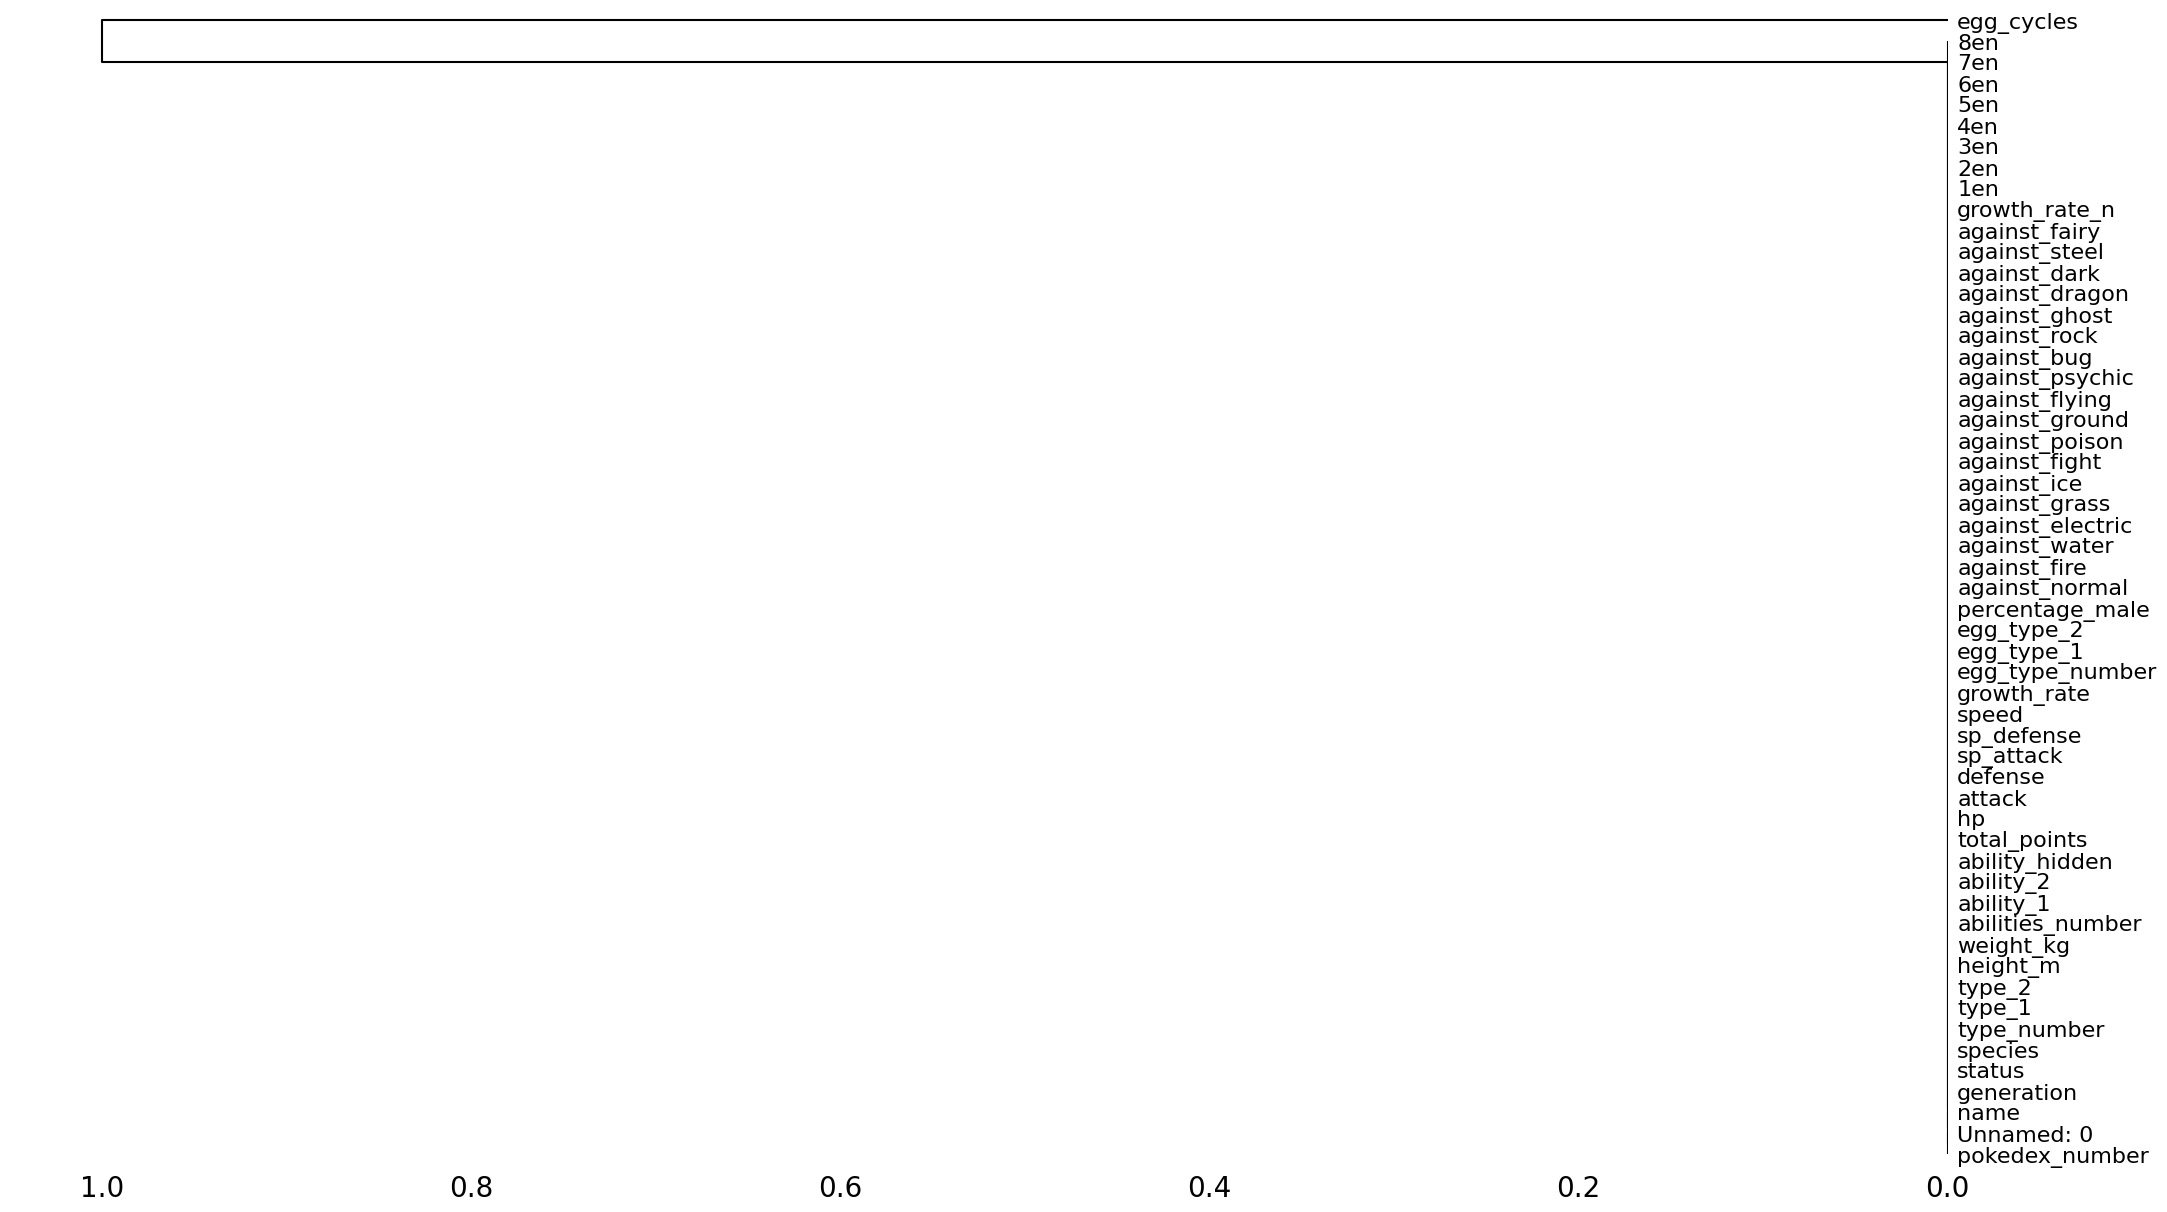

In [1015]:
msno.dendrogram(df)

In [1016]:
indices_to_remove = df.sample(frac=0.1, random_state=42).index
df.loc[indices_to_remove, column] = np.nan

NameError: name 'column' is not defined

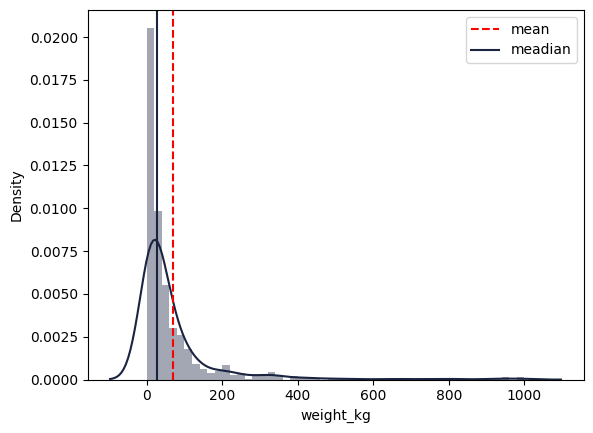

In [ ]:
sns.distplot(df.weight_kg)
plt.axvline(df.weight_kg.mean(), label = "mean", ls = "--", color = "r")
plt.axvline(df.weight_kg.median(), label = "meadian")
plt.legend()